# 초능력자 봇 유물 강화 시스템 A100 GPU 밸런싱 노트북

이 노트북은 업로드한 `data_analysis_report.txt`를 기반으로 다음을 한 번에 수행한다.

1. TXT 보고서 자동 파싱
2. 유저 포인트/정답/시도/최근활동 데이터 정리
3. 원자료 행이 부족할 경우 전체 요약 분포를 이용한 synthetic tail 복원
4. 강화·레벨업·드랍·합성 기대값 검산
5. 유저 활동량 시계열/준시계열 모델링  
   - 실제 이벤트 로그가 있으면 real panel 사용  
   - 없으면 누적 데이터와 최근활동 정보를 기반으로 pseudo panel 생성  
   - Zero-inflated Negative Binomial 패널 모델을 GPU로 적합
6. A100 GPU용 대규모 병렬 경제 시뮬레이터
7. Sobol/QMC 대량 파라미터 샘플링
8. Pareto ranking 기반 다목적 밸런싱
9. Surrogate-assisted refinement
10. 개발자 전달용 파라미터 후보표 export

핵심 구조:

```text
시계열 활동량 모델 → GPU 경제 시뮬레이터 → 다목적 파라미터 탐색
```

In [1]:
# ============================================================
# 0. Colab 런타임 체크
# ============================================================
import os, sys, math, re, json, random, warnings, time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
    torch.set_float32_matmul_precision("high")
else:
    print("GPU가 잡히지 않았음. Colab 런타임 유형을 GPU/A100으로 바꾸면 됨.")

DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB
CUDA capability: (8, 0)


## 1. 설정

`QUICK_MODE=True`는 구조 검산용이다.  
A100에서 본격 실행할 때는 `QUICK_MODE=False`로 바꿔라.

권장:

- 첫 검산: `QUICK_MODE=True`
- A100 실험: `QUICK_MODE=False`
- 매우 큰 실험: `K_TOTAL=32768`, `R_MC=16`, `BATCH_SIZE=128~256`

In [2]:
# ============================================================
# 1. 전역 설정
# ============================================================

BASE_DATE = pd.Timestamp("2026-05-03")  # 보고서 기준일

QUICK_MODE = False  # A100 본실험이면 False

if QUICK_MODE:
    K_TOTAL = 512
    R_MC = 4
    SIM_DAYS = 90
    BATCH_SIZE = 64
    ZINB_EPOCHS = 80
    SURROGATE_EPOCHS = 200
else:
    K_TOTAL = 8192
    R_MC = 16
    SIM_DAYS = 180
    BATCH_SIZE = 128
    ZINB_EPOCHS = 300
    SURROGATE_EPOCHS = 500

HISTORY_DAYS = 90
REPORT_DAYS = [30, 60, 90, 180]
REPORT_DAYS = [d for d in REPORT_DAYS if d <= SIM_DAYS]

MAX_LEVELUPS_PER_DAY = 3
MAX_ENHANCE_TRIES_PER_DAY = 8
MAX_SYNTH_LOOPS_PER_DAY = 2

OUTPUT_DIR = Path("/content/artifact_balance_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    "QUICK_MODE": QUICK_MODE,
    "K_TOTAL": K_TOTAL,
    "R_MC": R_MC,
    "SIM_DAYS": SIM_DAYS,
    "BATCH_SIZE": BATCH_SIZE,
    "REPORT_DAYS": REPORT_DAYS,
})

{'QUICK_MODE': False, 'K_TOTAL': 8192, 'R_MC': 16, 'SIM_DAYS': 180, 'BATCH_SIZE': 128, 'REPORT_DAYS': [30, 60, 90, 180]}


## 2. TXT 보고서 업로드/로드

Colab에 `data_analysis_report.txt`를 올려도 되고, `/content/drive/MyDrive/`에 넣어도 된다.

In [3]:
# ============================================================
# 2. 데이터 파일 찾기 / 업로드
# ============================================================

def find_or_upload_report() -> Path:
    candidates = [
        Path("/content/data_analysis_report.txt"),
        Path("/content/drive/MyDrive/data_analysis_report.txt"),
        Path("/mnt/data/data_analysis_report.txt"),
    ]
    for p in candidates:
        if p.exists():
            print("보고서 파일 발견:", p)
            return p

    try:
        from google.colab import files
        print("data_analysis_report.txt 파일을 업로드해라.")
        uploaded = files.upload()
        for name in uploaded.keys():
            if name.endswith(".txt"):
                p = Path("/content") / name
                print("업로드된 파일:", p)
                return p
    except Exception as e:
        print("Colab upload 사용 불가:", e)

    raise FileNotFoundError("data_analysis_report.txt를 찾지 못했음. /content/data_analysis_report.txt에 업로드해라.")

REPORT_PATH = find_or_upload_report()
text = REPORT_PATH.read_text(encoding="utf-8", errors="ignore")
print("글자 수:", len(text))
print(text[:500])

data_analysis_report.txt 파일을 업로드해라.


Saving data_analysis_report.txt to data_analysis_report.txt
업로드된 파일: /content/data_analysis_report.txt
글자 수: 23804
  초능력자 봇 데이터 분석 보고서
  기준일: 2026-05-03 (KST)
  ※ Production DB의 score 값에 ×10 적용 (미배포 상태이므로 원본 그대로)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] Production DB — 100P 이상 보유 유저 목록
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

■ 전체 요약
  - 전체 가입 유저 수 : 4,626명
  - 100P 이


## 3. TXT 파싱

보고서에서 다음을 자동 추출한다.

- 전체 유저 수, 평균 포인트, 최고 포인트
- 포인트 구간별 분포
- 전체 정답/시도 수
- 최근 활동 현황
- 유저별 행: 닉네임, 포인트, 정답수, 총시도, 정답률, 훈민정음 통계, 최근출석

In [4]:
# ============================================================
# 3. TXT 파서
# ============================================================

def parse_int_kr(s):
    if s is None:
        return None
    s = str(s).replace(",", "").replace("P", "").replace("명", "").replace("회", "").strip()
    m = re.search(r"-?\d+", s)
    return int(m.group()) if m else None

def parse_float_percent(s):
    if s is None:
        return np.nan
    s = str(s).replace("%", "").strip()
    try:
        return float(s) / 100.0
    except Exception:
        return np.nan

def extract_aggregate(text: str) -> dict:
    agg = {}

    patterns = {
        "total_users": r"전체 가입 유저 수\s*:\s*([\d,]+)명",
        "users_100p": r"100P 이상 유저 수\s*:\s*([\d,]+)명",
        "max_points": r"최고 포인트\s*:\s*([\d,]+)P",
        "mean_points": r"평균 포인트\s*:\s*([\d,]+)P",
        "total_correct": r"전체 정답 수 합계\s*:\s*([\d,]+)회",
        "total_attempts": r"전체 시도 수 합계\s*:\s*([\d,]+)회",
        "active_after_0501": r"2026-05-01 이후 활동\s*:\s*([\d,]+)명",
        "active_after_0502": r"2026-05-02 이후 활동\s*:\s*([\d,]+)명",
        "active_after_0503": r"2026-05-03 이후 활동\s*:\s*([\d,]+)명",
    }
    for k, pat in patterns.items():
        m = re.search(pat, text)
        if m:
            agg[k] = parse_int_kr(m.group(1))

    band_patterns = [
        ("100_999", r"100\s*~\s*999P\s*:\s*([\d,]+)명"),
        ("1000_9999", r"1,000\s*~\s*9,999P\s*:\s*([\d,]+)명"),
        ("10000_99999", r"10,000\s*~\s*99,999P\s*:\s*([\d,]+)명"),
        ("100000_999999", r"100,000\s*~\s*999,999P\s*:\s*([\d,]+)명"),
        ("1000000_plus", r"1,000,000P 이상\s*:\s*([\d,]+)명"),
    ]
    bands = {}
    for k, pat in band_patterns:
        m = re.search(pat, text)
        if m:
            bands[k] = parse_int_kr(m.group(1))
    agg["point_bands"] = bands
    return agg

def parse_user_rows(text: str) -> pd.DataFrame:
    rows = []
    for line in text.splitlines():
        if "|" not in line:
            continue
        parts = [p.strip() for p in line.split("|")]
        if len(parts) < 9:
            continue

        if "닉네임" in parts[0] or "유물명" in parts[0] or "typeId" in parts[0]:
            continue

        nickname = parts[0].strip()
        point = parse_int_kr(parts[1])
        correct = parse_int_kr(parts[2])
        attempts = parse_int_kr(parts[3])
        acc = parse_float_percent(parts[4])
        hunmin_wins = parse_int_kr(parts[5])
        hunmin_max = parse_int_kr(parts[6])
        hunmin_total = parse_int_kr(parts[7])
        last_attendance = parts[8].strip()

        if point is None or correct is None or attempts is None:
            continue
        if not re.search(r"[가-힣A-Za-z0-9_]", nickname):
            continue

        rows.append({
            "nickname": nickname,
            "points": point,
            "corrects": correct,
            "attempts": attempts,
            "accuracy": acc,
            "hunmin_wins": hunmin_wins or 0,
            "hunmin_max": hunmin_max or 0,
            "hunmin_total": hunmin_total or 0,
            "last_attendance": last_attendance,
            "source": "parsed",
        })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df["accuracy"] = df["corrects"] / df["attempts"].clip(lower=1)
    return df

agg = extract_aggregate(text)
df_parsed = parse_user_rows(text)

print("Aggregate:")
print(json.dumps(agg, ensure_ascii=False, indent=2))
print("\nParsed rows:", len(df_parsed))
display(df_parsed.head(10))

Aggregate:
{
  "total_users": 4626,
  "users_100p": 4586,
  "max_points": 1603600,
  "mean_points": 5647,
  "total_correct": 33846,
  "total_attempts": 99310,
  "active_after_0501": 518,
  "active_after_0502": 303,
  "active_after_0503": 43,
  "point_bands": {
    "100_999": 2426,
    "1000_9999": 1664,
    "10000_99999": 468,
    "100000_999999": 27,
    "1000000_plus": 1
  }
}

Parsed rows: 115


,nickname,points,corrects,attempts,accuracy,hunmin_wins,hunmin_max,hunmin_total,last_attendance,source
0,능력자_ea4997,1603600,3161,3230,0.978638,1,2,6,2026-05-01,parsed
1,능력자_d5dcad,643710,851,1488,0.571909,1,9,11,2026-05-03,parsed
2,능력자_66a071,605450,1165,1288,0.904503,1,6,9,2026-05-02,parsed
3,부운영진_6a1c4c,523180,939,1010,0.929703,12,21,169,2026-05-03,parsed
4,능력자_fb3f51,404070,542,1266,0.428120,0,0,0,(없음),parsed
5,능력자_97b77b,357680,714,807,0.884758,3,4,21,2026-05-01,parsed
6,능력자_609a16,268710,358,595,0.601681,5,8,46,2026-05-01,parsed
7,능력자_42d98a,243130,466,602,0.774086,3,6,15,2026-05-02,parsed
8,능력자_55db3b,216070,347,520,0.667308,7,4,14,2026-04-29,parsed
9,능력자_751098,173470,239,330,0.724242,1,4,4,2026-05-02,parsed


## 4. 원자료 행이 부족할 때 synthetic tail 복원

보고서에 상위 일부 유저만 있고 “이하 4,500여 명”처럼 요약되어 있을 수 있다.  
그 경우 포인트 구간별 분포와 총 정답/시도 수를 이용해서 나머지 유저를 생성한다.

이건 실제 유저를 위조한다는 뜻이 아니라, **서버 경제 시뮬레이션의 초기 분포를 맞추기 위한 synthetic population**이다.

In [5]:
# ============================================================
# 4. Synthetic tail 생성
# ============================================================

POINT_BANDS = {
    "under_100": (0, 99),
    "100_999": (100, 999),
    "1000_9999": (1000, 9999),
    "10000_99999": (10000, 99999),
    "100000_999999": (100000, 999999),
    "1000000_plus": (1000000, 2000000),
}

def band_of_point(p):
    for k, (lo, hi) in POINT_BANDS.items():
        if lo <= p <= hi:
            return k
    return "1000000_plus" if p >= 1000000 else "under_100"

def loguniform_int(lo, hi, size, rng):
    if hi <= 0:
        return rng.integers(lo, hi+1, size=size)
    x = np.exp(rng.uniform(np.log(max(1, lo)), np.log(hi), size=size))
    return np.clip(np.round(x), lo, hi).astype(int)

def complete_population(df: pd.DataFrame, agg: dict, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    df = df.copy()

    total_users = int(agg.get("total_users", len(df)))
    users_100p = int(agg.get("users_100p", max(len(df), total_users)))
    bands = agg.get("point_bands", {})

    target_counts = {"under_100": max(0, total_users - users_100p)}
    target_counts.update(bands)

    parsed_band_counts = df["points"].map(band_of_point).value_counts().to_dict() if len(df) else {}

    synth_rows = []
    synth_idx = 0

    for band, target_n in target_counts.items():
        lo, hi = POINT_BANDS[band]
        existing = parsed_band_counts.get(band, 0)
        need = max(0, int(target_n) - int(existing))
        if need <= 0:
            continue

        pts = loguniform_int(lo, hi, need, rng)
        for p in pts:
            synth_rows.append({
                "nickname": f"synthetic_{synth_idx:05d}",
                "points": int(p),
                "corrects": 0,
                "attempts": 0,
                "accuracy": np.nan,
                "hunmin_wins": 0,
                "hunmin_max": 0,
                "hunmin_total": 0,
                "last_attendance": "(없음)",
                "source": "synthetic",
            })
            synth_idx += 1

    if synth_rows:
        df = pd.concat([df, pd.DataFrame(synth_rows)], ignore_index=True)

    target_total_points = agg.get("mean_points", None)
    if target_total_points is not None:
        target_sum = int(target_total_points) * total_users
        parsed_mask = df["source"].eq("parsed")
        synth_mask = df["source"].eq("synthetic")
        parsed_sum = df.loc[parsed_mask, "points"].sum()
        synth_sum = df.loc[synth_mask, "points"].sum()
        need_sum = max(0, target_sum - parsed_sum)

        if synth_mask.sum() > 0 and synth_sum > 0 and need_sum > 0:
            factor = need_sum / synth_sum
            new_pts = np.round(df.loc[synth_mask, "points"].to_numpy() * factor).astype(int)
            new_pts = np.clip(new_pts, 0, max(agg.get("max_points", 2000000), 2000000))
            df.loc[synth_mask, "points"] = new_pts

    target_correct = agg.get("total_correct", None)
    target_attempts = agg.get("total_attempts", None)

    synth_mask = df["source"].eq("synthetic")
    parsed_correct = int(df.loc[~synth_mask, "corrects"].sum())
    parsed_attempts = int(df.loc[~synth_mask, "attempts"].sum())

    if synth_mask.sum() > 0 and target_correct is not None:
        remaining_correct = max(0, int(target_correct) - parsed_correct)
        weights = np.sqrt(df.loc[synth_mask, "points"].to_numpy() + 1.0)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones_like(weights) / len(weights)
        synth_corrects = rng.multinomial(remaining_correct, weights)
        df.loc[synth_mask, "corrects"] = synth_corrects

    if synth_mask.sum() > 0 and target_attempts is not None:
        remaining_attempts = max(0, int(target_attempts) - parsed_attempts)
        weights = df.loc[synth_mask, "corrects"].to_numpy().astype(float) + 1.0
        weights = weights / weights.sum()
        synth_attempts = rng.multinomial(remaining_attempts, weights)
        synth_attempts = np.maximum(synth_attempts, df.loc[synth_mask, "corrects"].to_numpy())
        df.loc[synth_mask, "attempts"] = synth_attempts

    df["attempts"] = df["attempts"].clip(lower=0).astype(int)
    df["corrects"] = df["corrects"].clip(lower=0).astype(int)
    df["accuracy"] = df["corrects"] / df["attempts"].clip(lower=1)

    def parsed_date_level(x):
        if x == "2026-05-03":
            return 3
        if x == "2026-05-02":
            return 2
        if x == "2026-05-01":
            return 1
        return 0

    df["recent_level"] = df["last_attendance"].map(parsed_date_level).fillna(0).astype(int)

    if synth_mask.sum() > 0:
        n3 = int(agg.get("active_after_0503", 0))
        n2 = max(0, int(agg.get("active_after_0502", 0)) - n3)
        n1 = max(0, int(agg.get("active_after_0501", 0)) - int(agg.get("active_after_0502", 0)))

        current = df.loc[~synth_mask, "recent_level"].value_counts().to_dict()
        need3 = max(0, n3 - current.get(3, 0))
        need2 = max(0, n2 - current.get(2, 0))
        need1 = max(0, n1 - current.get(1, 0))

        available = list(df.index[synth_mask].to_numpy())
        for level, need in [(3, need3), (2, need2), (1, need1)]:
            need = min(need, len(available))
            if need <= 0:
                continue
            avail_arr = np.array(available)
            weights = np.log1p(df.loc[avail_arr, "points"].to_numpy()) + 1
            weights = weights / weights.sum()
            chosen = rng.choice(avail_arr, size=need, replace=False, p=weights)
            df.loc[chosen, "recent_level"] = level
            chosen_set = set(chosen.tolist())
            available = [x for x in available if x not in chosen_set]

    df["is_recent_active"] = df["recent_level"].ge(1)
    df["point_rank_pct"] = df["points"].rank(pct=True)
    df["user_class"] = pd.cut(
        df["point_rank_pct"],
        bins=[0, 0.5, 0.85, 0.97, 1.0],
        labels=[0, 1, 2, 3],
        include_lowest=True
    ).astype(int)

    return df.reset_index(drop=True)

df_users = complete_population(df_parsed, agg, seed=SEED)
print("Final users:", len(df_users))
print(df_users["source"].value_counts())
display(df_users.head())
display(df_users[["points","corrects","attempts","accuracy","recent_level","user_class"]].describe())

Final users: 4626
source
synthetic    4511
parsed        115
Name: count, dtype: int64


,nickname,points,corrects,attempts,accuracy,hunmin_wins,hunmin_max,hunmin_total,last_attendance,source,recent_level,is_recent_active,point_rank_pct,user_class
0,능력자_ea4997,1603600,3161,3230,0.978638,1,2,6,2026-05-01,parsed,1,True,1.000000,3
1,능력자_d5dcad,643710,851,1488,0.571909,1,9,11,2026-05-03,parsed,3,True,0.999784,3
2,능력자_66a071,605450,1165,1288,0.904503,1,6,9,2026-05-02,parsed,2,True,0.999568,3
3,부운영진_6a1c4c,523180,939,1010,0.929703,12,21,169,2026-05-03,parsed,3,True,0.999351,3
4,능력자_fb3f51,404070,542,1266,0.428120,0,0,0,(없음),parsed,0,False,0.999135,3


,points,corrects,attempts,accuracy,recent_level,user_class
count,4.626000e+03,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000
mean,5.647013e+03,7.316472,21.468655,0.212044,0.186770,0.680502
std,3.256254e+04,57.687877,78.254440,0.141878,0.565806,0.798618
min,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.822500e+02,1.000000,5.000000,0.133677,0.000000,0.000000
50%,5.530000e+02,2.000000,10.000000,0.222222,0.000000,1.000000
75%,2.540500e+03,5.000000,18.000000,0.285714,0.000000,1.000000
max,1.603600e+06,3161.000000,3230.000000,1.000000,3.000000,3.000000


## 5. EDA: 현재 경제 분포 확인

여기서 상위권 꼬리, 정답률, 활동 유저 구조를 먼저 본다.

{
  "n_users": 4626,
  "points_sum": 26123081,
  "points_mean": 5647.012753999135,
  "points_median": 553.0,
  "points_p90": 7484.0,
  "points_p99": 64062.0,
  "points_max": 1603600,
  "total_corrects": 33846,
  "total_attempts": 99314,
  "overall_accuracy": 0.3407978734116036,
  "recent_active": 518
}


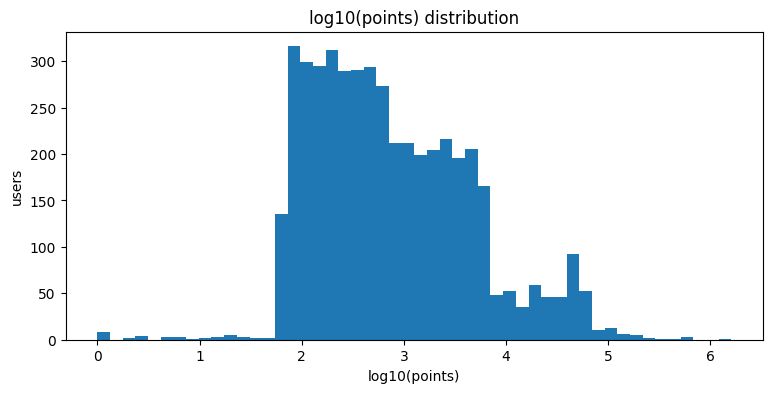

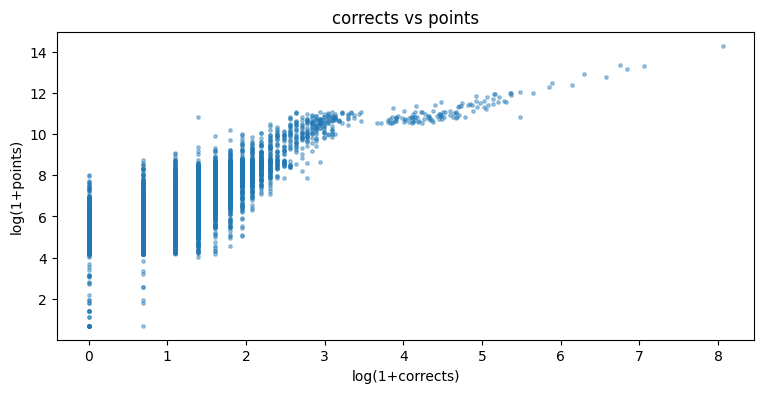

In [6]:
# ============================================================
# 5. EDA
# ============================================================

summary = {
    "n_users": len(df_users),
    "points_sum": int(df_users["points"].sum()),
    "points_mean": float(df_users["points"].mean()),
    "points_median": float(df_users["points"].median()),
    "points_p90": float(df_users["points"].quantile(0.90)),
    "points_p99": float(df_users["points"].quantile(0.99)),
    "points_max": int(df_users["points"].max()),
    "total_corrects": int(df_users["corrects"].sum()),
    "total_attempts": int(df_users["attempts"].sum()),
    "overall_accuracy": float(df_users["corrects"].sum() / max(1, df_users["attempts"].sum())),
    "recent_active": int(df_users["is_recent_active"].sum()),
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(df_users["points"].clip(lower=1)), bins=50)
ax.set_title("log10(points) distribution")
ax.set_xlabel("log10(points)")
ax.set_ylabel("users")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(np.log1p(df_users["corrects"]), np.log1p(df_users["points"]), s=6, alpha=0.4)
ax.set_xlabel("log(1+corrects)")
ax.set_ylabel("log(1+points)")
ax.set_title("corrects vs points")
plt.show()

## 6. 강화·레벨업 기대값 검산

GPU 시뮬레이션 전에 현재 파라미터가 어느 정도 난이도인지 closed-form으로 확인한다.

In [7]:
# ============================================================
# 6. 기대값 계산
# ============================================================

SUCCESS_TABLE = np.array([
    0.90, 0.85, 0.80, 0.75, 0.70,
    0.65, 0.60, 0.55, 0.50, 0.45,
    0.40, 0.35, 0.30, 0.25, 0.20,
    0.15, 0.10, 0.08, 0.05, 0.03
], dtype=np.float64)

BASE_EFFECT = np.array([0.02, 0.04, 0.08, 0.15, 0.25], dtype=np.float64)
DROP_PROBS = np.array([0.03, 0.008, 0.0015, 0.0003, 0.0], dtype=np.float64)
DISMANTLE_REFUND = np.array([500, 2000, 8000, 30000, 100000], dtype=np.float64)
SYNTH_COST = np.array([1000, 3000, 10000, 40000], dtype=np.float64)

def expected_enhance_cost(grade=1, H=20, base=500, growth=1.5, success_table=SUCCESS_TABLE):
    costs = []
    total = 0.0
    for h in range(H):
        c = math.floor(grade * base * (growth ** h))
        ev = c / success_table[h]
        total += ev
        costs.append((h, h+1, c, success_table[h], ev, total))
    return pd.DataFrame(costs, columns=["from","to","cost","p_success","ev_step","ev_cum"])

ev_rows = []
for grade_name, grade in zip(["D","C","B","A","S"], [1,2,3,4,5]):
    ev = expected_enhance_cost(grade=grade)
    row = {"grade": grade_name}
    for H in [5,10,15,20]:
        row[f"+{H}_EV"] = ev.loc[H-1, "ev_cum"]
    ev_rows.append(row)

ev_table = pd.DataFrame(ev_rows)
display(ev_table)

level_rows = []
for grade_name, grade in zip(["D","C","B","A","S"], [1,2,3,4,5]):
    total_level_cost = sum(grade * 300 * l for l in range(1, 30))
    level_rows.append({"grade": grade_name, "level_1_to_30_cost": total_level_cost})
display(pd.DataFrame(level_rows))

drop_ev_refund = float((DROP_PROBS * DISMANTLE_REFUND).sum())
print("정답 1회당 유물 드랍의 분해환급 기대가치:", drop_ev_refund)

,grade,+5_EV,+10_EV,+15_EV,+20_EV
0,D,8709.206116,107913.115207,1.638858e+06,6.426674e+07
1,C,17419.745565,215833.142612,3.277738e+06,1.285336e+08
2,B,26128.951681,323753.836685,4.916610e+06,1.928004e+08
3,A,34840.919701,431674.737106,6.555490e+06,2.570672e+08
4,S,43550.125817,539595.431178,8.194361e+06,3.213341e+08


,grade,level_1_to_30_cost
0,D,130500
1,C,261000
2,B,391500
3,A,522000
4,S,652500


정답 1회당 유물 드랍의 분해환급 기대가치: 52.0


## 7. 시계열/준시계열 패널 만들기

실제 이벤트 로그가 있으면 `/content/event_log.csv`를 우선 사용한다.

권장 실제 로그 스키마:

```text
timestamp,user_id,event_type,game_type,point_before,point_delta,point_after,
correct,attempt,artifact_grade,artifact_level,artifact_enhance,cost,success
```

현재 TXT만 있으면 누적 정답/시도/최근출석을 바탕으로 pseudo daily panel을 생성한다.

실제 event_log.csv 없음. pseudo daily panel 생성.
(90, 4626)


,0
2026-04-29,1344
2026-04-30,1389
2026-05-01,1433
2026-05-02,1747
2026-05-03,1657


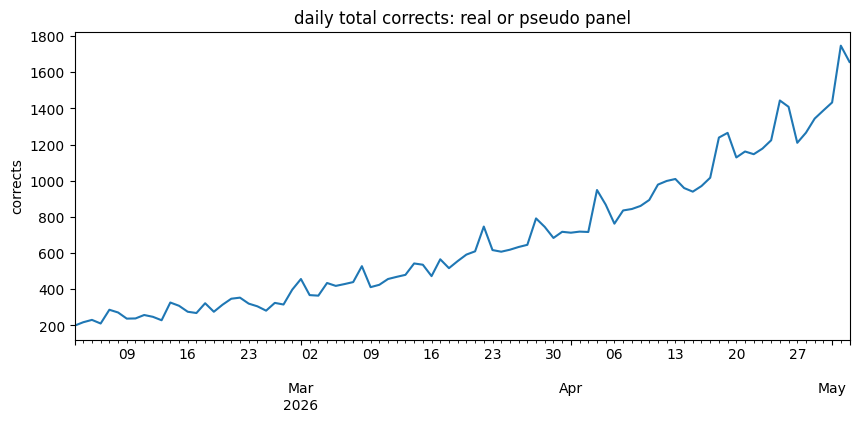

In [8]:
# ============================================================
# 7. Daily panel 생성
# ============================================================

def load_real_event_log_if_exists(path="/content/event_log.csv"):
    p = Path(path)
    if not p.exists():
        return None
    log = pd.read_csv(p)
    log["timestamp"] = pd.to_datetime(log["timestamp"])
    log["date"] = log["timestamp"].dt.date
    return log

def make_daily_panel_from_log(log: pd.DataFrame, df_users: pd.DataFrame, days=HISTORY_DAYS):
    end = BASE_DATE.normalize()
    dates = pd.date_range(end=end, periods=days, freq="D")
    user_index = pd.Series(np.arange(len(df_users)), index=df_users["nickname"].astype(str)).to_dict()

    panel = pd.DataFrame(0, index=dates, columns=np.arange(len(df_users)), dtype=np.int16)

    if "user_id" in log.columns:
        tmp = log.copy()
        tmp["user_idx"] = tmp["user_id"].astype(str).map(user_index)
        tmp = tmp.dropna(subset=["user_idx"])
        tmp["user_idx"] = tmp["user_idx"].astype(int)
        if "correct" in tmp.columns:
            tmp_correct = tmp[tmp["correct"].astype(bool)]
        elif "event_type" in tmp.columns:
            tmp_correct = tmp[tmp["event_type"].astype(str).str.contains("correct|answer", case=False, regex=True)]
        else:
            tmp_correct = tmp
        g = tmp_correct.groupby([pd.to_datetime(tmp_correct["date"]), "user_idx"]).size()
        for (d, i), val in g.items():
            d = pd.Timestamp(d)
            if d in panel.index:
                panel.loc[d, i] = val

    return panel

def make_pseudo_daily_panel(df_users: pd.DataFrame, days=HISTORY_DAYS, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(end=BASE_DATE.normalize(), periods=days, freq="D")
    N = len(df_users)

    points = df_users["points"].to_numpy()
    corrects = df_users["corrects"].to_numpy()
    acc = df_users["accuracy"].fillna(0).to_numpy()
    recent = df_users["recent_level"].to_numpy()
    uclass = df_users["user_class"].to_numpy()

    base = (
        0.02
        + 0.020 * np.sqrt(np.maximum(corrects, 0))
        + 0.10 * np.log1p(points) / np.log(1 + max(1, points.max()))
        + 0.20 * acc
        + np.array([0.0, 0.40, 0.75, 1.30])[np.clip(recent, 0, 3)]
        + np.array([0.00, 0.05, 0.15, 0.35])[np.clip(uclass, 0, 3)]
    )
    base = np.clip(base, 0.005, 25.0)

    t = np.arange(days)
    recency_weight = np.exp((t - days + 1) / 45.0)
    weekday = np.array([d.weekday() for d in dates])
    weekend_boost = np.where(weekday >= 5, 1.15, 1.0)
    day_effect = recency_weight * weekend_boost
    day_effect = day_effect / day_effect.mean()

    Y = np.zeros((days, N), dtype=np.int16)
    dispersion = 2.0

    for ti in range(days):
        mu = base * day_effect[ti]
        zi = 1 / (1 + np.exp(-(
            1.5
            - 0.55*np.log1p(corrects)
            - 0.65*recent
            - 0.35*uclass
        )))
        active_mask = rng.random(N) > zi
        lam = rng.gamma(shape=dispersion, scale=np.maximum(mu, 1e-6)/dispersion)
        y = rng.poisson(lam)
        y = y * active_mask
        Y[ti] = np.clip(y, 0, 100).astype(np.int16)

    panel = pd.DataFrame(Y, index=dates, columns=np.arange(N))
    return panel

real_log = load_real_event_log_if_exists()
if real_log is not None:
    print("실제 event_log.csv 발견. 실제 로그 기반 daily panel 생성.")
    daily_panel = make_daily_panel_from_log(real_log, df_users, days=HISTORY_DAYS)
else:
    print("실제 event_log.csv 없음. pseudo daily panel 생성.")
    daily_panel = make_pseudo_daily_panel(df_users, days=HISTORY_DAYS, seed=SEED)

print(daily_panel.shape)
display(daily_panel.sum(axis=1).tail())
fig, ax = plt.subplots(figsize=(10, 4))
daily_panel.sum(axis=1).plot(ax=ax)
ax.set_title("daily total corrects: real or pseudo panel")
ax.set_ylabel("corrects")
plt.show()

## 8. GPU Zero-inflated Negative Binomial 패널 모델

유저별 하루 정답 수 \(Y_{i,t}\)를 다음처럼 본다.

\[
Y_{i,t} \sim 	ext{ZINB}(\mu_{i,t}, \phi, \pi_{i,t})
\]

\[
\log \mu_{i,t}
=
lpha_i + \delta_t + x_i^\topeta
\]

\[
	ext{logit}(\pi_{i,t})
=
\zeta_0 + x_i^\top\gamma
\]

- \(lpha_i\): 유저별 기본 활동성
- \(\delta_t\): 날짜 효과
- \(x_i\): 포인트, 정답률, 최근활동, 유저 클래스 등
- \(\pi_{i,t}\): 구조적 0, 즉 그날 아예 안 할 확률

fit ZINB:   0%|          | 0/300 [00:00<?, ?it/s]

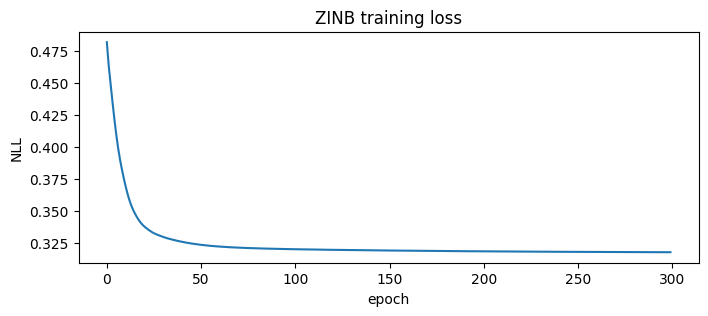

dispersion: 1.9022716283798218
mu mean: 0.25934284925460815 zi mean: 0.6038622260093689


In [9]:
# ============================================================
# 8. ZINB 패널 모델
# ============================================================

def standardize_np(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-6)

features_np = np.column_stack([
    standardize_np(np.log1p(df_users["points"].to_numpy())),
    standardize_np(np.log1p(df_users["corrects"].to_numpy())),
    standardize_np(df_users["accuracy"].fillna(0).to_numpy()),
    standardize_np(df_users["recent_level"].to_numpy()),
    standardize_np(df_users["user_class"].to_numpy()),
]).astype(np.float32)

Y_np = daily_panel.to_numpy().astype(np.float32)
T_hist, N_USERS = Y_np.shape
F_DIM = features_np.shape[1]

Y_torch = torch.tensor(Y_np, device=DEVICE)
X_torch = torch.tensor(features_np, device=DEVICE)

class ZINBPanel(nn.Module):
    def __init__(self, n_users, n_days, f_dim):
        super().__init__()
        self.user_log_base = nn.Parameter(torch.zeros(n_users))
        self.day_effect = nn.Parameter(torch.zeros(n_days))
        self.beta = nn.Parameter(torch.zeros(f_dim))
        self.zero_intercept = nn.Parameter(torch.tensor(0.0))
        self.zero_beta = nn.Parameter(torch.zeros(f_dim))
        self.log_dispersion = nn.Parameter(torch.tensor(math.log(2.0)))

    def forward(self, X):
        eta_user = self.user_log_base[None, :]
        eta_day = self.day_effect[:, None]
        eta_feat = (X @ self.beta)[None, :]
        log_mu = eta_user + eta_day + eta_feat
        mu = torch.exp(torch.clamp(log_mu, -8, 6))

        zi_logits = self.zero_intercept + (X @ self.zero_beta)
        zi_prob = torch.sigmoid(zi_logits)[None, :].expand_as(mu)

        dispersion = F.softplus(self.log_dispersion) + 1e-4
        return mu, zi_prob, dispersion

def zinb_nll(y, mu, zi_prob, dispersion):
    r = dispersion
    eps = 1e-8

    log_mu = torch.log(mu + eps)
    log_r = torch.log(r + eps)
    log_r_mu = torch.log(r + mu + eps)

    log_nb = (
        torch.lgamma(y + r)
        - torch.lgamma(r)
        - torch.lgamma(y + 1)
        + r * (log_r - log_r_mu)
        + y * (log_mu - log_r_mu)
    )

    log_pi = torch.log(zi_prob + eps)
    log_1m_pi = torch.log1p(-zi_prob + eps)

    is_zero = (y < 0.5)
    zero_logprob = torch.logaddexp(log_pi, log_1m_pi + log_nb)
    nonzero_logprob = log_1m_pi + log_nb
    logprob = torch.where(is_zero, zero_logprob, nonzero_logprob)

    return -logprob.mean()

zinb_model = ZINBPanel(N_USERS, T_hist, F_DIM).to(DEVICE)

with torch.no_grad():
    user_mean = torch.log1p(Y_torch.mean(dim=0))
    day_mean = torch.log1p(Y_torch.mean(dim=1))
    zinb_model.user_log_base.copy_(user_mean - user_mean.mean())
    zinb_model.day_effect.copy_(day_mean - day_mean.mean())

opt = torch.optim.AdamW(zinb_model.parameters(), lr=0.03, weight_decay=1e-4)

losses = []
pbar = tqdm(range(ZINB_EPOCHS), desc="fit ZINB")
for epoch in pbar:
    opt.zero_grad()
    mu, zi, disp = zinb_model(X_torch)
    loss = zinb_nll(Y_torch, mu, zi, disp)
    reg = 1e-4 * (zinb_model.user_log_base.pow(2).mean() + zinb_model.day_effect.pow(2).mean())
    total_loss = loss + reg
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(zinb_model.parameters(), 5.0)
    opt.step()

    losses.append(float(loss.detach().cpu()))
    if epoch % 20 == 0:
        pbar.set_postfix(loss=losses[-1], disp=float(disp.detach().cpu()))

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("ZINB training loss")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.show()

with torch.no_grad():
    mu_fit, zi_fit, disp_fit = zinb_model(X_torch)
    print("dispersion:", float(disp_fit.detach().cpu()))
    print("mu mean:", float(mu_fit.mean().detach().cpu()), "zi mean:", float(zi_fit.mean().detach().cpu()))

## 9. 미래 활동량 예측

학습된 \(\mu_{i,t}\), \(\pi_{i,t}\)를 바탕으로 미래 \(T\)일의 유저별 활동량 분포를 만든다.

여기서는 날짜 효과를 최근 7일 패턴 반복 + 약한 추세로 예측한다.

future mu: torch.Size([180, 4626]) future zi: torch.Size([180, 4626])
mean future mu: 0.5539129972457886 mean zi: 0.6038622260093689


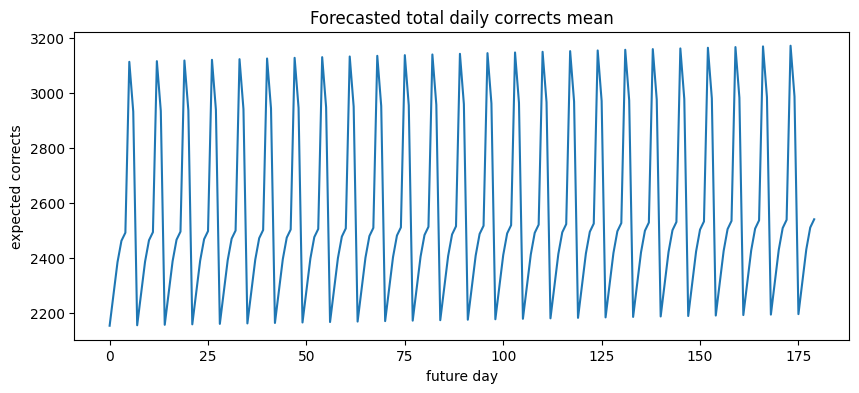

In [10]:
# ============================================================
# 9. 미래 활동량 forecast
# ============================================================

@torch.no_grad()
def forecast_activity(model: ZINBPanel, X, future_days=SIM_DAYS):
    model.eval()
    mu_hist, zi_hist, dispersion = model(X)

    day_eff = model.day_effect.detach()
    last7 = day_eff[-7:] if len(day_eff) >= 7 else day_eff
    reps = math.ceil(future_days / len(last7))
    future_day_eff = last7.repeat(reps)[:future_days]

    if len(day_eff) >= 28:
        recent_mean = day_eff[-14:].mean()
        prev_mean = day_eff[-28:-14].mean()
        trend = torch.clamp(recent_mean - prev_mean, -0.02, 0.02)
    else:
        trend = torch.tensor(0.0, device=DEVICE)
    trend_vec = torch.arange(future_days, device=DEVICE).float() * trend / max(1, future_days)

    eta_user = model.user_log_base.detach()[None, :]
    eta_feat = (X @ model.beta.detach())[None, :]
    log_mu_future = eta_user + future_day_eff[:, None] + trend_vec[:, None] + eta_feat
    mu_future = torch.exp(torch.clamp(log_mu_future, -8, 6))

    zi_logits = model.zero_intercept.detach() + (X @ model.zero_beta.detach())
    zi_future = torch.sigmoid(zi_logits)[None, :].expand_as(mu_future)

    return mu_future, zi_future, dispersion.detach()

mu_future, zi_future, dispersion_future = forecast_activity(zinb_model, X_torch, future_days=SIM_DAYS)

print("future mu:", mu_future.shape, "future zi:", zi_future.shape)
print("mean future mu:", float(mu_future.mean().detach().cpu()), "mean zi:", float(zi_future.mean().detach().cpu()))

plt.figure(figsize=(10,4))
plt.plot(mu_future.sum(dim=1).detach().cpu().numpy())
plt.title("Forecasted total daily corrects mean")
plt.xlabel("future day")
plt.ylabel("expected corrects")
plt.show()

## 10. 파라미터 탐색 공간

Sobol/QMC로 파라미터 후보를 대량 생성한다.

초기 탐색 대상:

- 평균 보상
- 활동량 보정
- 강화 비용 기본값
- 강화 비용 증가율
- 강화 성공률 스케일
- 레벨업 비용 기본값
- D/C/B/A 드랍률
- 합성 비용 스케일
- 합성 성공률 스케일
- 유물 효과 스케일
- 유저별 소비 성향

In [11]:
# ============================================================
# 10. Sobol/QMC 파라미터 샘플링
# ============================================================

PARAM_BOUNDS = {
    "reward_base":        (500.0, 1200.0),
    "activity_scale":     (0.70, 1.50),

    "enhance_cost_base":  (300.0, 800.0),
    "enhance_growth":     (1.25, 1.70),
    "enhance_success_scale": (0.75, 1.20),

    "level_cost_base":    (150.0, 500.0),

    "drop_D":             (0.010, 0.050),
    "drop_C":             (0.003, 0.015),
    "drop_B":             (0.0005, 0.0040),
    "drop_A":             (0.00005, 0.0008),

    "synth_cost_scale":   (0.50, 2.00),
    "synth_success_scale":(0.75, 1.25),

    "effect_scale":       (0.70, 1.25),

    "spend_low":          (0.08, 0.25),
    "spend_mid":          (0.18, 0.45),
    "spend_high":         (0.35, 0.75),
    "spend_whale":        (0.55, 0.95),
}

PARAM_NAMES = list(PARAM_BOUNDS.keys())
P_DIM = len(PARAM_NAMES)

def sample_sobol_params(K: int, seed=42) -> pd.DataFrame:
    engine = torch.quasirandom.SobolEngine(dimension=P_DIM, scramble=True, seed=seed)
    u = engine.draw(K).cpu().numpy()
    data = {}
    for j, name in enumerate(PARAM_NAMES):
        lo, hi = PARAM_BOUNDS[name]
        data[name] = lo + (hi - lo) * u[:, j]
    df = pd.DataFrame(data)
    df.insert(0, "theta_id", np.arange(K))
    return df

theta_df = sample_sobol_params(K_TOTAL, seed=SEED)
display(theta_df.head())
print(theta_df.describe().T[["min","mean","max"]])

,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,drop_A,synth_cost_scale,synth_success_scale,effect_scale,spend_low,spend_mid,spend_high,spend_whale
0,0,1198.259277,0.783493,711.489441,1.438744,0.987745,169.684250,0.028212,0.011990,0.001274,0.000513,1.715142,0.856145,0.721140,0.229910,0.355670,0.616634,0.878373
1,1,742.992798,1.152788,421.698578,1.583411,0.960447,428.358002,0.047933,0.008569,0.002263,0.000231,1.068330,1.006279,1.000106,0.150489,0.196375,0.492206,0.665605
2,2,507.553528,1.023124,642.931702,1.347136,0.809022,358.560730,0.013438,0.005680,0.003793,0.000307,0.759968,1.166225,0.919865,0.182689,0.258312,0.672887,0.638138
3,3,951.893188,1.441283,431.754089,1.646730,1.118119,277.749359,0.032546,0.014258,0.001491,0.000766,1.272036,0.938391,1.190240,0.091439,0.419716,0.448452,0.805839
4,4,906.207031,0.977979,341.269775,1.614256,1.162053,199.795517,0.018606,0.003059,0.003174,0.000140,0.650251,0.915012,0.892686,0.140350,0.396801,0.389978,0.789983


                              min         mean          max
theta_id                 0.000000  4095.500000  8191.000000
reward_base            500.014709   850.000000  1199.944824
activity_scale           0.700079     1.100000     1.499981
enhance_cost_base      300.034363   550.000000   799.953430
enhance_growth           1.250007     1.475000     1.699981
enhance_success_scale    0.750050     0.975000     1.199946
level_cost_base        150.035751   325.000000   499.998199
drop_D                   0.010002     0.030000     0.049999
drop_C                   0.003001     0.009000     0.014999
drop_B                   0.000500     0.002250     0.004000
drop_A                   0.000050     0.000425     0.000800
synth_cost_scale         0.500115     1.250000     1.999937
synth_success_scale      0.750033     1.000000     1.249996
effect_scale             0.700014     0.975000     1.249948
spend_low                0.080009     0.165000     0.249990
spend_mid                0.180006     0.

## 11. GPU 경제 시뮬레이터

상태 텐서 구조:

\[
	ext{state}_{k,r,i,t}
\]

- \(k\): 파라미터 후보
- \(r\): 몬테카를로 반복
- \(i\): 유저
- \(t\): 날짜

핵심은 **유저 for-loop를 없애는 것**이다.  
A100 활용은 `[B, R, N]` 텐서 병렬화에서 나온다.

In [12]:
# ============================================================
# 11. GPU simulator 준비 텐서
# ============================================================

init_points = torch.tensor(df_users["points"].to_numpy(np.float32), device=DEVICE)
init_corrects = torch.tensor(df_users["corrects"].to_numpy(np.float32), device=DEVICE)
init_attempts = torch.tensor(df_users["attempts"].to_numpy(np.float32), device=DEVICE)
user_class_t = torch.tensor(df_users["user_class"].to_numpy(np.int64), device=DEVICE)
recent_active_t = torch.tensor(df_users["is_recent_active"].to_numpy(np.bool_), device=DEVICE)

SUCCESS_TABLE_T = torch.tensor(SUCCESS_TABLE.astype(np.float32), device=DEVICE)
BASE_EFFECT_T = torch.tensor(np.concatenate([[0.0], BASE_EFFECT]).astype(np.float32), device=DEVICE)
DISMANTLE_REFUND_T = torch.tensor(DISMANTLE_REFUND.astype(np.float32), device=DEVICE)
SYNTH_COST_T = torch.tensor(SYNTH_COST.astype(np.float32), device=DEVICE)

def theta_batch_to_tensors(theta_batch: pd.DataFrame, device=DEVICE):
    out = {}
    for name in PARAM_NAMES:
        out[name] = torch.tensor(theta_batch[name].to_numpy(np.float32), device=device)
    out["theta_id"] = torch.tensor(theta_batch["theta_id"].to_numpy(np.int64), device=device)
    return out

def sample_zinb_counts(mu, zi_prob, dispersion):
    eps = 1e-6
    r = torch.clamp(dispersion, min=0.05, max=100.0)
    rate = r / torch.clamp(mu, min=eps)
    lam = torch.distributions.Gamma(concentration=r, rate=rate).sample()
    y = torch.poisson(lam)
    zero_mask = torch.rand_like(y) < zi_prob
    y = torch.where(zero_mask, torch.zeros_like(y), y)
    return torch.clamp(y, 0, 200)

def binomial_sample(total_count, probs):
    probs = torch.clamp(probs, 0.0, 0.95)
    return torch.distributions.Binomial(total_count=total_count, probs=probs).sample()

def compute_effect(main_grade, main_level, main_enhance, effect_scale):
    base = BASE_EFFECT_T[main_grade.clamp(0,5)]
    level_mult = 1.0 + (main_level.float() - 1.0).clamp(min=0) * 0.05
    enhance_mult = 1.0 + main_enhance.float().clamp(min=0) * 0.03
    return base * level_mult * enhance_mult * effect_scale[:, None, None]

def equip_best_artifact(counts, main_grade, main_level, main_enhance):
    for g in range(5, 0, -1):
        idx = g - 1
        has = counts[..., idx] > 0
        better = has & (main_grade < g)
        if better.any():
            counts[..., idx] = torch.where(better, counts[..., idx] - 1, counts[..., idx])
            main_grade = torch.where(better, torch.full_like(main_grade, g), main_grade)
            main_level = torch.where(better, torch.ones_like(main_level), main_level)
            main_enhance = torch.where(better, torch.zeros_like(main_enhance), main_enhance)
    return counts, main_grade, main_level, main_enhance

def dismantle_excess(counts, points, inventory_limit=8):
    total = counts.sum(dim=-1)
    excess = torch.clamp(total - inventory_limit, min=0)
    total_refund = torch.zeros_like(points)
    for g in range(5):
        take = torch.minimum(counts[..., g], excess)
        counts[..., g] = counts[..., g] - take
        refund = take.float() * DISMANTLE_REFUND_T[g]
        points = points + refund
        total_refund = total_refund + refund
        excess = excess - take
    return counts, points, total_refund

def run_synthesis(counts, points, theta):
    total_sink = torch.zeros_like(points)
    for _ in range(MAX_SYNTH_LOOPS_PER_DAY):
        for g in range(4):
            possible = torch.div(counts[..., g], 3, rounding_mode="floor")
            attempts = torch.clamp(possible, 0, 3)

            base_cost = SYNTH_COST_T[g] * theta["synth_cost_scale"][:, None, None]
            cost = attempts.float() * base_cost
            can = (attempts > 0) & (points >= cost)

            actual_attempts = torch.where(can, attempts, torch.zeros_like(attempts))
            if actual_attempts.sum() <= 0:
                continue

            base_success = ((g+1) * 15.0 + 16.0) / 100.0
            p = torch.clamp(base_success * theta["synth_success_scale"][:, None, None], 0.05, 0.95)

            successes = binomial_sample(actual_attempts.float(), p).long()

            counts[..., g] = counts[..., g] - actual_attempts * 3
            counts[..., g+1] = counts[..., g+1] + successes
            points = points - cost
            total_sink = total_sink + cost

    return counts, points, total_sink

def collect_metrics(points, main_grade, main_level, main_enhance, counts,
                    total_inflow, total_sink, total_refund, got_drop_7):
    B, R, N = points.shape
    active = recent_active_t[None, None, :].expand(B, R, N)
    active_f = active.float()
    active_den = active_f.sum(dim=-1).clamp(min=1)

    def active_rate(mask):
        return ((mask & active).float().sum(dim=-1) / active_den).mean(dim=1)

    reach_d5 = active_rate(main_enhance >= 5)
    reach_d10 = active_rate(main_enhance >= 10)
    reach_d15 = active_rate(main_enhance >= 15)
    reach_d20 = active_rate(main_enhance >= 20)

    has_B = active_rate(main_grade >= 3)
    has_A = active_rate(main_grade >= 4)
    has_S = active_rate(main_grade >= 5)

    q = torch.quantile(points.float(), torch.tensor([0.5, 0.9, 0.99], device=DEVICE), dim=-1)
    p50 = q[0].mean(dim=1)
    p90 = q[1].mean(dim=1)
    p99 = q[2].mean(dim=1)
    inequality = p99 / torch.clamp(p50, min=1.0)

    effect = compute_effect(main_grade, main_level, main_enhance, torch.ones(B, device=DEVICE))
    mean_bonus = effect.mean(dim=-1).mean(dim=1)
    q_bonus = torch.quantile(effect.float(), torch.tensor([0.99], device=DEVICE), dim=-1)[0].mean(dim=1)

    sink = total_sink.mean(dim=1)
    inflow = total_inflow.mean(dim=1)
    refund = total_refund.mean(dim=1)
    sink_ratio = sink / torch.clamp(inflow + refund, min=1.0)

    drop7 = ((got_drop_7 & active).float().sum(dim=-1) / active_den).mean(dim=1)
    spare_total = counts.sum(dim=(-1, -2)).float().mean(dim=1)

    return {
        "reach_d5": reach_d5,
        "reach_d10": reach_d10,
        "reach_d15": reach_d15,
        "reach_d20": reach_d20,
        "has_B": has_B,
        "has_A": has_A,
        "has_S": has_S,
        "p50": p50,
        "p90": p90,
        "p99": p99,
        "p99_p50": inequality,
        "mean_bonus": mean_bonus,
        "p99_bonus": q_bonus,
        "sink": sink,
        "inflow": inflow,
        "refund": refund,
        "sink_ratio": sink_ratio,
        "drop7": drop7,
        "spare_total": spare_total,
    }

@torch.no_grad()
def simulate_batch(theta: Dict[str, torch.Tensor],
                   mu_future: torch.Tensor,
                   zi_future: torch.Tensor,
                   dispersion: torch.Tensor,
                   R=R_MC,
                   sim_days=SIM_DAYS,
                   report_days=REPORT_DAYS):
    B = theta["reward_base"].shape[0]
    N = init_points.shape[0]

    points = init_points[None, None, :].expand(B, R, N).clone()

    main_grade = torch.zeros((B, R, N), device=DEVICE, dtype=torch.long)
    main_level = torch.ones((B, R, N), device=DEVICE, dtype=torch.long)
    main_enhance = torch.zeros((B, R, N), device=DEVICE, dtype=torch.long)

    counts = torch.zeros((B, R, N, 5), device=DEVICE, dtype=torch.long)

    total_inflow = torch.zeros((B, R), device=DEVICE)
    total_sink = torch.zeros((B, R), device=DEVICE)
    total_refund = torch.zeros((B, R), device=DEVICE)

    got_drop_7 = torch.zeros((B, R, N), device=DEVICE, dtype=torch.bool)

    spend_table = torch.stack([
        theta["spend_low"],
        theta["spend_mid"],
        theta["spend_high"],
        theta["spend_whale"],
    ], dim=1)
    spend_ratio = spend_table[:, user_class_t]
    spend_ratio = spend_ratio[:, None, :]

    snapshot_metrics = {}

    for day in range(sim_days):
        mu_day = mu_future[day][None, None, :].expand(B, R, N)
        zi_day = zi_future[day][None, None, :].expand(B, R, N)

        effect = compute_effect(main_grade, main_level, main_enhance, theta["effect_scale"])
        mu_day = mu_day * theta["activity_scale"][:, None, None] * (1.0 + 0.15 * effect)
        daily_corrects = sample_zinb_counts(mu_day, zi_day, dispersion)

        reward = daily_corrects * theta["reward_base"][:, None, None] * (1.0 + effect)
        points = points + reward
        total_inflow = total_inflow + reward.sum(dim=-1)

        drop_probs = [
            theta["drop_D"],
            theta["drop_C"],
            theta["drop_B"],
            theta["drop_A"],
            torch.zeros_like(theta["drop_D"]),
        ]

        any_drop_today = torch.zeros((B, R, N), device=DEVICE, dtype=torch.bool)
        for g in range(4):
            p = drop_probs[g][:, None, None]
            d = binomial_sample(daily_corrects, p).long()
            counts[..., g] = counts[..., g] + d
            any_drop_today |= d > 0

        if day < 7:
            got_drop_7 |= any_drop_today

        counts, main_grade, main_level, main_enhance = equip_best_artifact(
            counts, main_grade, main_level, main_enhance
        )

        for _ in range(MAX_LEVELUPS_PER_DAY):
            grade_f = main_grade.float()
            level_f = main_level.float()
            cost = grade_f * theta["level_cost_base"][:, None, None] * level_f
            can = (
                (main_grade > 0)
                & (main_level < 30)
                & (points >= cost)
                & (points * spend_ratio >= cost)
            )
            pay = torch.where(can, cost, torch.zeros_like(cost))
            points = points - pay
            total_sink = total_sink + pay.sum(dim=-1)
            main_level = torch.where(can, main_level + 1, main_level)

        for _ in range(MAX_ENHANCE_TRIES_PER_DAY):
            h = main_enhance.clamp(0, 19)
            grade_f = main_grade.float()
            cost = grade_f * theta["enhance_cost_base"][:, None, None] * (
                theta["enhance_growth"][:, None, None] ** h.float()
            )
            p_success = SUCCESS_TABLE_T[h] * theta["enhance_success_scale"][:, None, None]
            p_success = torch.clamp(p_success, 0.01, 0.95)

            can = (
                (main_grade > 0)
                & (main_enhance < 20)
                & (points >= cost)
                & (points * spend_ratio >= cost)
            )
            rand = torch.rand_like(points)
            success = can & (rand < p_success)
            pay = torch.where(can, cost, torch.zeros_like(cost))
            points = points - pay
            total_sink = total_sink + pay.sum(dim=-1)
            main_enhance = torch.where(success, main_enhance + 1, main_enhance)

        counts, points, synth_sink = run_synthesis(counts, points, theta)
        total_sink = total_sink + synth_sink.sum(dim=-1)

        counts, main_grade, main_level, main_enhance = equip_best_artifact(
            counts, main_grade, main_level, main_enhance
        )

        counts, points, refund = dismantle_excess(counts, points, inventory_limit=8)
        total_refund = total_refund + refund.sum(dim=-1)

        d = day + 1
        if d in report_days:
            snapshot_metrics[d] = collect_metrics(
                points, main_grade, main_level, main_enhance,
                counts, total_inflow, total_sink, total_refund, got_drop_7
            )

    final_metrics = collect_metrics(
        points, main_grade, main_level, main_enhance,
        counts, total_inflow, total_sink, total_refund, got_drop_7
    )

    return final_metrics, snapshot_metrics

print("Simulator ready.")

Simulator ready.


## 12. 대량 시뮬레이션 실행

`K_TOTAL`개의 파라미터 후보를 batch 단위로 GPU에 올려 평가한다.

출력은 후보별 30/60/90/180일 지표다.

In [13]:
# ============================================================
# 12. 대량 시뮬레이션 실행
# ============================================================

def metrics_to_cpu_df(metrics: Dict[str, torch.Tensor], theta_batch: pd.DataFrame, prefix="final"):
    out = theta_batch[["theta_id"] + PARAM_NAMES].copy()
    for k, v in metrics.items():
        out[f"{prefix}_{k}"] = v.detach().cpu().numpy()
    return out

def run_parameter_sweep(theta_df: pd.DataFrame,
                        batch_size=BATCH_SIZE,
                        R=R_MC,
                        sim_days=SIM_DAYS):
    all_final = []
    all_snapshots = {d: [] for d in REPORT_DAYS}

    n = len(theta_df)
    for start in tqdm(range(0, n, batch_size), desc="GPU parameter sweep"):
        end = min(start + batch_size, n)
        batch = theta_df.iloc[start:end].reset_index(drop=True)
        theta = theta_batch_to_tensors(batch, device=DEVICE)

        final_metrics, snapshots = simulate_batch(
            theta, mu_future, zi_future, dispersion_future,
            R=R, sim_days=sim_days, report_days=REPORT_DAYS
        )

        all_final.append(metrics_to_cpu_df(final_metrics, batch, prefix=f"d{sim_days}"))

        for d, m in snapshots.items():
            all_snapshots[d].append(metrics_to_cpu_df(m, batch, prefix=f"d{d}"))

        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    final_df = pd.concat(all_final, ignore_index=True)
    snap_dfs = {}
    for d, parts in all_snapshots.items():
        if parts:
            snap_dfs[d] = pd.concat(parts, ignore_index=True)
    return final_df, snap_dfs

start_time = time.time()
final_df, snap_dfs = run_parameter_sweep(theta_df, batch_size=BATCH_SIZE, R=R_MC, sim_days=SIM_DAYS)
print("elapsed sec:", time.time() - start_time)

display(final_df.head())
print(final_df.shape)

final_df.to_csv(OUTPUT_DIR / "sweep_final_metrics.csv", index=False)
for d, sdf in snap_dfs.items():
    sdf.to_csv(OUTPUT_DIR / f"sweep_d{d}_metrics.csv", index=False)

print("saved to", OUTPUT_DIR)

GPU parameter sweep:   0%|          | 0/64 [00:00<?, ?it/s]

elapsed sec: 854.0650146007538


,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,...,d180_p99,d180_p99_p50,d180_mean_bonus,d180_p99_bonus,d180_sink,d180_inflow,d180_refund,d180_sink_ratio,d180_drop7,d180_spare_total
0,0,1198.259277,0.783493,711.489441,1.438744,0.987745,169.684250,0.028212,0.011990,0.001274,...,68511.484375,9.361187,0.040915,0.267135,240166784.0,258498432.0,50406.25,0.928903,0.255912,2314.4375
1,1,742.992798,1.152788,421.698578,1.583411,0.960447,428.358002,0.047933,0.008569,0.002263,...,75971.953125,7.260704,0.041034,0.218073,203553456.0,239731648.0,18187.50,0.849024,0.423625,3454.8125
2,2,507.553528,1.023124,642.931702,1.347136,0.809022,358.560730,0.013438,0.005680,0.003793,...,50143.632812,7.207045,0.033018,0.209986,124798608.0,143202800.0,4281.25,0.871456,0.199445,1812.0625
3,3,951.893188,1.441283,431.754089,1.646730,1.118119,277.749359,0.032546,0.014258,0.001491,...,141747.796875,12.718161,0.058883,0.367564,358310784.0,406023296.0,105156.25,0.882260,0.428089,4002.4375
4,4,906.207031,0.977979,341.269775,1.614256,1.162053,199.795517,0.018606,0.003059,0.003174,...,91250.632812,9.785811,0.038331,0.245245,202135584.0,246749488.0,375.00,0.819192,0.204392,1679.0000


(8192, 37)
saved to /content/artifact_balance_outputs


## 13. 다목적 점수화와 Pareto ranking

단일 점수로도 정렬하고, Pareto front도 따로 뽑는다.

기본 운영 목표 예시:

- 30일 또는 최종 기준 D+5는 활동 유저 35~60%
- D+10은 10~25%
- D+15는 0~5%
- S등급은 매우 희소
- P99/P50 격차가 너무 커지지 않음
- Sink ratio는 0.6~1.2 근처
- 7일 내 드랍 경험은 어느 정도 있어야 함

In [14]:
# ============================================================
# 13. 목적함수 / Pareto ranking
# ============================================================

def add_balance_scores(df: pd.DataFrame, prefix: str):
    df = df.copy()

    target = {
        "reach_d5": 0.50,
        "reach_d10": 0.16,
        "reach_d15_max": 0.04,
        "has_S_max": 0.005,
        "sink_ratio": 0.85,
        "drop7": 0.25,
        "p99_p50_max": 120.0,
        "p99_bonus_max": 0.80,
    }

    def col(x): return f"{prefix}_{x}"

    loss = 0.0
    loss += 2.0 * (df[col("reach_d5")] - target["reach_d5"]).abs()
    loss += 2.5 * (df[col("reach_d10")] - target["reach_d10"]).abs()
    loss += 4.0 * np.maximum(0, df[col("reach_d15")] - target["reach_d15_max"])
    loss += 6.0 * np.maximum(0, df[col("has_S")] - target["has_S_max"])
    loss += 1.5 * (df[col("sink_ratio")] - target["sink_ratio"]).abs()
    loss += 1.0 * np.maximum(0, target["drop7"] - df[col("drop7")])
    loss += 0.01 * np.maximum(0, df[col("p99_p50")] - target["p99_p50_max"])
    loss += 2.0 * np.maximum(0, df[col("p99_bonus")] - target["p99_bonus_max"])

    df["balance_loss"] = loss
    df["balance_score"] = 1.0 / (1.0 + loss)

    df["obj_growth"] = -np.abs(df[col("reach_d5")] - target["reach_d5"]) - np.abs(df[col("reach_d10")] - target["reach_d10"])
    df["obj_rarity"] = -np.maximum(0, df[col("reach_d15")] - target["reach_d15_max"]) - np.maximum(0, df[col("has_S")] - target["has_S_max"])
    df["obj_economy"] = -np.abs(df[col("sink_ratio")] - target["sink_ratio"]) - 0.005*np.maximum(0, df[col("p99_p50")] - target["p99_p50_max"])
    df["obj_fun"] = -np.abs(df[col("drop7")] - target["drop7"])

    return df

def pareto_efficient_max(values: np.ndarray):
    n = values.shape[0]
    is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_eff[i]:
            continue
        others = values[is_eff]
        dominated = np.any(np.all(others >= values[i], axis=1) & np.any(others > values[i], axis=1))
        if dominated:
            is_eff[i] = False
    return is_eff

PREFIX = f"d{SIM_DAYS}"
ranked_df = add_balance_scores(final_df, prefix=PREFIX)
ranked_df = ranked_df.sort_values("balance_loss").reset_index(drop=True)

top_for_pareto = ranked_df.head(min(2000, len(ranked_df))).copy()
vals = top_for_pareto[["obj_growth","obj_rarity","obj_economy","obj_fun"]].to_numpy()
front_mask = pareto_efficient_max(vals)
pareto_df = top_for_pareto.loc[front_mask].sort_values("balance_loss").reset_index(drop=True)

display(ranked_df.head(20))
print("Pareto candidates:", len(pareto_df))
display(pareto_df.head(20))

ranked_df.to_csv(OUTPUT_DIR / "ranked_candidates.csv", index=False)
pareto_df.to_csv(OUTPUT_DIR / "pareto_candidates.csv", index=False)

,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,...,d180_refund,d180_sink_ratio,d180_drop7,d180_spare_total,balance_loss,balance_score,obj_growth,obj_rarity,obj_economy,obj_fun
0,6143,1198.427490,1.454598,748.018921,1.654854,0.971327,202.449478,0.044481,0.004896,0.001512,...,375.00,0.851398,0.453668,3495.8125,0.378509,0.725422,-0.150709,-0.0,-0.001398,-0.203668
1,4095,1198.005737,1.316962,671.180542,1.603927,0.756702,171.877792,0.037311,0.012708,0.000917,...,48468.75,0.869194,0.421815,3714.2500,0.379563,0.724867,-0.140816,-0.0,-0.019194,-0.171815
2,4801,761.556030,1.176612,751.015930,1.444717,0.925006,272.197571,0.030942,0.006863,0.003330,...,22781.25,0.849855,0.340613,3057.0000,0.383265,0.722927,-0.153243,-0.0,-0.000145,-0.090613
3,6256,1142.687134,0.941239,587.271790,1.696126,0.897740,246.925842,0.041472,0.004010,0.001411,...,250.00,0.852359,0.319136,2369.9375,0.390266,0.719287,-0.155053,-0.0,-0.002359,-0.069136
4,7184,1120.822021,0.857606,557.570251,1.624893,0.911048,174.629715,0.038943,0.004407,0.002873,...,31.25,0.855549,0.298142,2305.1875,0.397284,0.715674,-0.157466,-0.0,-0.005549,-0.048142
5,7728,1155.739746,0.862811,797.163330,1.574840,0.788121,321.506042,0.041213,0.007054,0.000691,...,10312.50,0.844964,0.304537,2380.5625,0.399530,0.714525,-0.156984,-0.0,-0.005036,-0.054537
6,4085,603.804138,1.357426,515.629395,1.688408,0.883619,432.330963,0.032897,0.014206,0.001286,...,29156.25,0.850714,0.412886,3656.5000,0.401432,0.713556,-0.160241,-0.0,-0.000714,-0.162886
7,2795,875.501587,1.301446,664.056335,1.557434,0.945824,151.308243,0.015799,0.008227,0.001809,...,3343.75,0.857428,0.256636,2389.0625,0.402333,0.713097,-0.160603,-0.0,-0.007428,-0.006636
8,5023,1176.563599,1.144214,779.673645,1.613642,0.951238,306.862335,0.037028,0.004687,0.002758,...,31.25,0.841639,0.357264,2921.6875,0.403613,0.712447,-0.156622,-0.0,-0.008361,-0.107264
9,5056,1182.537720,0.928936,682.417175,1.663081,0.834482,341.899292,0.028722,0.012179,0.000673,...,37656.25,0.847317,0.284870,2527.6250,0.406739,0.710864,-0.161810,-0.0,-0.002683,-0.034870


Pareto candidates: 47


,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,...,d180_refund,d180_sink_ratio,d180_drop7,d180_spare_total,balance_loss,balance_score,obj_growth,obj_rarity,obj_economy,obj_fun
0,6143,1198.427490,1.454598,748.018921,1.654854,0.971327,202.449478,0.044481,0.004896,0.001512,...,375.00,0.851398,0.453668,3495.8125,0.378509,0.725422,-0.150709,-0.0,-0.001398,-0.203668
1,4095,1198.005737,1.316962,671.180542,1.603927,0.756702,171.877792,0.037311,0.012708,0.000917,...,48468.75,0.869194,0.421815,3714.2500,0.379563,0.724867,-0.140816,-0.0,-0.019194,-0.171815
2,4801,761.556030,1.176612,751.015930,1.444717,0.925006,272.197571,0.030942,0.006863,0.003330,...,22781.25,0.849855,0.340613,3057.0000,0.383265,0.722927,-0.153243,-0.0,-0.000145,-0.090613
3,6256,1142.687134,0.941239,587.271790,1.696126,0.897740,246.925842,0.041472,0.004010,0.001411,...,250.00,0.852359,0.319136,2369.9375,0.390266,0.719287,-0.155053,-0.0,-0.002359,-0.069136
4,7184,1120.822021,0.857606,557.570251,1.624893,0.911048,174.629715,0.038943,0.004407,0.002873,...,31.25,0.855549,0.298142,2305.1875,0.397284,0.715674,-0.157466,-0.0,-0.005549,-0.048142
5,7728,1155.739746,0.862811,797.163330,1.574840,0.788121,321.506042,0.041213,0.007054,0.000691,...,10312.50,0.844964,0.304537,2380.5625,0.399530,0.714525,-0.156984,-0.0,-0.005036,-0.054537
6,2795,875.501587,1.301446,664.056335,1.557434,0.945824,151.308243,0.015799,0.008227,0.001809,...,3343.75,0.857428,0.256636,2389.0625,0.402333,0.713097,-0.160603,-0.0,-0.007428,-0.006636
7,5056,1182.537720,0.928936,682.417175,1.663081,0.834482,341.899292,0.028722,0.012179,0.000673,...,37656.25,0.847317,0.284870,2527.6250,0.406739,0.710864,-0.161810,-0.0,-0.002683,-0.034870
8,4181,617.712585,1.163328,652.918030,1.582306,1.077648,457.701172,0.017029,0.013723,0.001251,...,12218.75,0.850835,0.284749,2618.8125,0.409578,0.709432,-0.164223,-0.0,-0.000835,-0.034749
9,4995,958.280396,1.475869,719.671692,1.676311,1.047597,412.319489,0.019082,0.010956,0.003736,...,6750.00,0.850134,0.351955,3392.1875,0.410095,0.709172,-0.165068,-0.0,-0.000134,-0.101955


## 14. 결과 시각화

상위 후보들의 주요 지표를 확인한다.

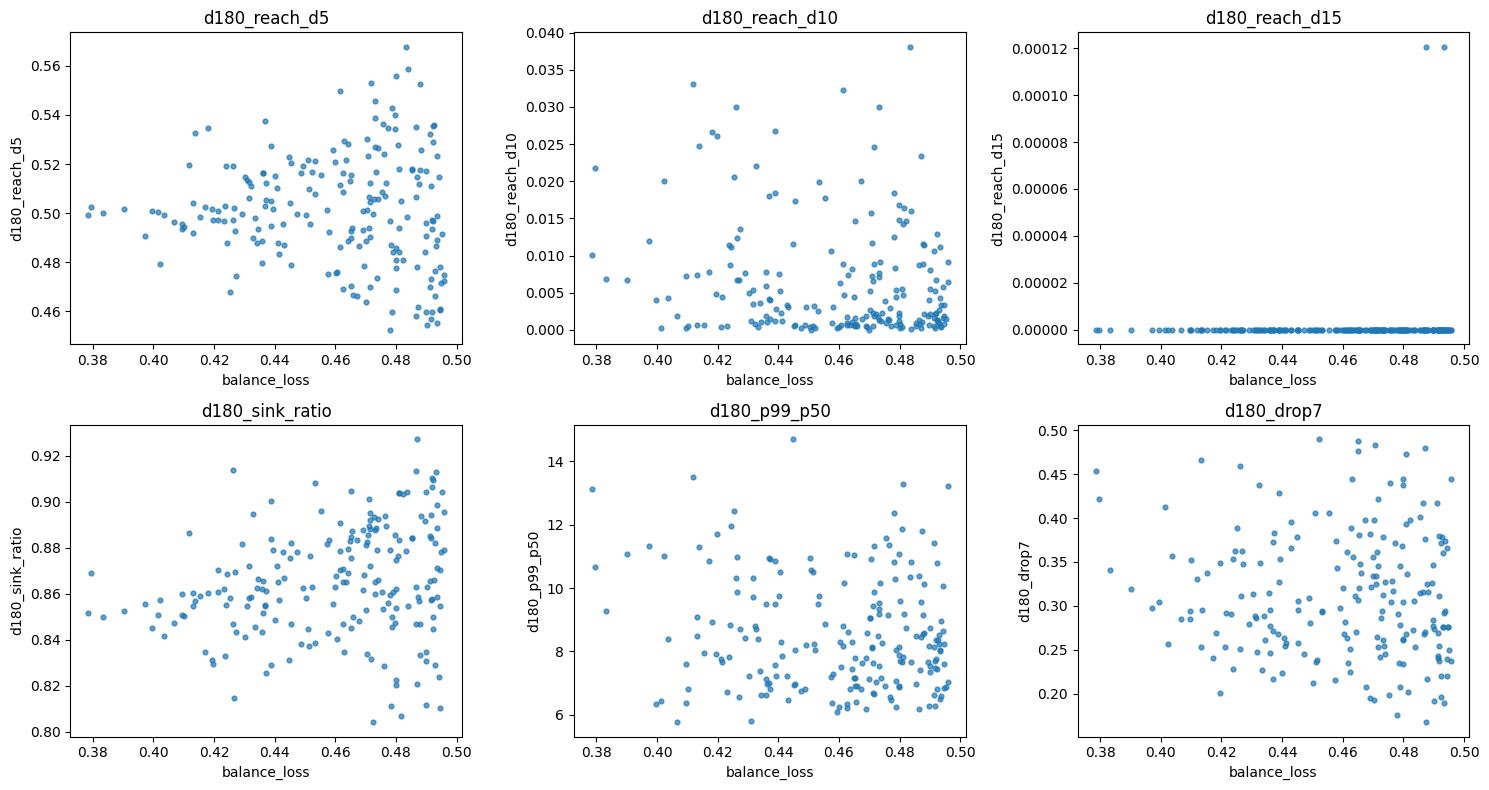

,theta_id,balance_loss,balance_score,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,...,d180_reach_d5,d180_reach_d10,d180_reach_d15,d180_has_A,d180_has_S,d180_sink_ratio,d180_p99_p50,d180_drop7,d180_mean_bonus,d180_p99_bonus
0,6143,0.378509,0.725422,1198.427490,1.454598,748.018921,1.654854,0.971327,202.449478,0.044481,...,0.499276,0.010014,0.0,0.100145,0.000121,0.851398,13.130366,0.453668,0.054404,0.299688
1,4095,0.379563,0.724867,1198.005737,1.316962,671.180542,1.603927,0.756702,171.877792,0.037311,...,0.502534,0.021718,0.0,0.182432,0.000483,0.869194,10.656080,0.421815,0.058280,0.393383
2,4801,0.383265,0.722927,761.556030,1.176612,751.015930,1.444717,0.925006,272.197571,0.030942,...,0.500121,0.006877,0.0,0.229247,0.001327,0.849855,9.288130,0.340613,0.047763,0.307786
3,6256,0.390266,0.719287,1142.687134,0.941239,587.271790,1.696126,0.897740,246.925842,0.041472,...,0.501810,0.006757,0.0,0.052968,0.000000,0.852359,11.066413,0.319136,0.036966,0.234428
4,7184,0.397284,0.715674,1120.822021,0.857606,557.570251,1.624893,0.911048,174.629715,0.038943,...,0.490589,0.011945,0.0,0.111728,0.000000,0.855549,11.319333,0.298142,0.043760,0.286380
5,7728,0.399530,0.714525,1155.739746,0.862811,797.163330,1.574840,0.788121,321.506042,0.041213,...,0.500965,0.003982,0.0,0.055864,0.000000,0.844964,6.340267,0.304537,0.032524,0.205376
6,4085,0.401432,0.713556,603.804138,1.357426,515.629395,1.688408,0.883619,432.330963,0.032897,...,0.500483,0.000241,0.0,0.060690,0.000000,0.850714,6.425888,0.412886,0.040801,0.198097
7,2795,0.402333,0.713097,875.501587,1.301446,664.056335,1.557434,0.945824,151.308243,0.015799,...,0.479368,0.020029,0.0,0.190999,0.000483,0.857428,11.001847,0.256636,0.052420,0.374613
8,5023,0.403613,0.712447,1176.563599,1.144214,779.673645,1.613642,0.951238,306.862335,0.037028,...,0.499035,0.004344,0.0,0.169522,0.000603,0.841639,8.390772,0.357264,0.047841,0.311753
9,5056,0.406739,0.710864,1182.537720,0.928936,682.417175,1.663081,0.834482,341.899292,0.028722,...,0.496380,0.001810,0.0,0.018822,0.000000,0.847317,5.754838,0.284870,0.034359,0.190975


In [15]:
# ============================================================
# 14. 결과 시각화
# ============================================================

plot_df = ranked_df.head(min(200, len(ranked_df))).copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

metrics = [
    f"{PREFIX}_reach_d5",
    f"{PREFIX}_reach_d10",
    f"{PREFIX}_reach_d15",
    f"{PREFIX}_sink_ratio",
    f"{PREFIX}_p99_p50",
    f"{PREFIX}_drop7",
]

for ax, m in zip(axes, metrics):
    ax.scatter(plot_df["balance_loss"], plot_df[m], s=12, alpha=0.7)
    ax.set_xlabel("balance_loss")
    ax.set_ylabel(m)
    ax.set_title(m)

plt.tight_layout()
plt.show()

cols = ["theta_id", "balance_loss", "balance_score"] + PARAM_NAMES + [
    f"{PREFIX}_reach_d5", f"{PREFIX}_reach_d10", f"{PREFIX}_reach_d15",
    f"{PREFIX}_has_A", f"{PREFIX}_has_S", f"{PREFIX}_sink_ratio",
    f"{PREFIX}_p99_p50", f"{PREFIX}_drop7", f"{PREFIX}_mean_bonus", f"{PREFIX}_p99_bonus"
]
display(ranked_df[cols].head(10))

## 15. Surrogate-assisted refinement

1차 GPU 시뮬레이션 결과로 신경망 surrogate를 학습한다.  
그다음 훨씬 많은 파라미터 후보를 surrogate로 빠르게 예측하고, 상위 후보만 다시 실제 GPU 시뮬레이션한다.

이 방식이 A100을 가장 연구스럽게 쓰는 방식이다.

train surrogate:   0%|          | 0/500 [00:00<?, ?it/s]

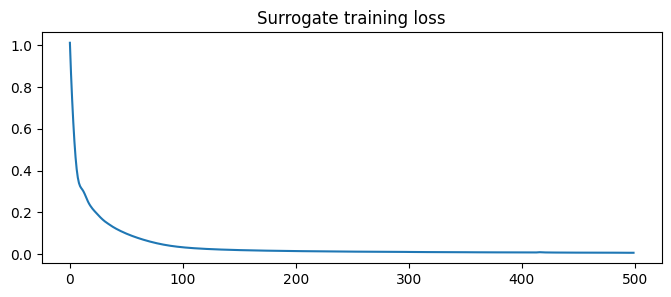

,theta_id,balance_loss,pred_balance_loss
0,6143,0.378509,0.464908
1,4095,0.379563,0.405737
2,4801,0.383265,0.424677
3,6256,0.390266,0.463751
4,7184,0.397284,0.459234
5,7728,0.399530,0.447127
6,4085,0.401432,0.492147
7,2795,0.402333,0.398845
8,5023,0.403613,0.414528
9,5056,0.406739,0.482231


In [16]:
# ============================================================
# 15. Surrogate model 학습
# ============================================================

SURROGATE_TARGETS = [
    f"{PREFIX}_reach_d5",
    f"{PREFIX}_reach_d10",
    f"{PREFIX}_reach_d15",
    f"{PREFIX}_has_A",
    f"{PREFIX}_has_S",
    f"{PREFIX}_sink_ratio",
    f"{PREFIX}_p99_p50",
    f"{PREFIX}_drop7",
    f"{PREFIX}_mean_bonus",
    f"{PREFIX}_p99_bonus",
    "balance_loss",
]

train_df = ranked_df.dropna(subset=PARAM_NAMES + SURROGATE_TARGETS).copy()

X = train_df[PARAM_NAMES].to_numpy(np.float32)
Y = train_df[SURROGATE_TARGETS].to_numpy(np.float32)

x_mean, x_std = X.mean(axis=0), X.std(axis=0) + 1e-6
y_mean, y_std = Y.mean(axis=0), Y.std(axis=0) + 1e-6

Xn = (X - x_mean) / x_std
Yn = (Y - y_mean) / y_std

X_t = torch.tensor(Xn, device=DEVICE)
Y_t = torch.tensor(Yn, device=DEVICE)

class SurrogateMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden//2),
            nn.GELU(),
            nn.Linear(hidden//2, out_dim),
        )

    def forward(self, x):
        return self.net(x)

surrogate = SurrogateMLP(P_DIM, len(SURROGATE_TARGETS)).to(DEVICE)
opt = torch.optim.AdamW(surrogate.parameters(), lr=1e-3, weight_decay=1e-4)

losses = []
for epoch in tqdm(range(SURROGATE_EPOCHS), desc="train surrogate"):
    opt.zero_grad()
    pred = surrogate(X_t)
    loss = F.mse_loss(pred, Y_t)
    loss.backward()
    opt.step()
    losses.append(float(loss.detach().cpu()))

plt.figure(figsize=(8,3))
plt.plot(losses)
plt.title("Surrogate training loss")
plt.show()

with torch.no_grad():
    pred = surrogate(X_t).detach().cpu().numpy() * y_std + y_mean
pred_df = pd.DataFrame(pred, columns=[f"pred_{c}" for c in SURROGATE_TARGETS])
display(pd.concat([train_df[["theta_id","balance_loss"]].reset_index(drop=True), pred_df[["pred_balance_loss"]]], axis=1).head(10))

## 16. Surrogate로 대량 후보 예측 후 재시뮬레이션

`REFINE_K`를 크게 잡을수록 “경우의 수 검토”가 강해진다.  
A100이면 100,000~1,000,000개 후보를 surrogate로 예측하고, 상위 256~1024개만 다시 실제 시뮬레이션하는 방식이 좋다.

In [17]:
# ============================================================
# 16. Surrogate-assisted 후보 재탐색
# ============================================================

REFINE_K = 20000 if QUICK_MODE else 200000
RESIM_K = 128 if QUICK_MODE else 512

refine_theta = sample_sobol_params(REFINE_K, seed=SEED+777)
Xr = refine_theta[PARAM_NAMES].to_numpy(np.float32)
Xrn = (Xr - x_mean) / x_std

with torch.no_grad():
    pred_norm = []
    bs = 8192
    for st in range(0, len(Xrn), bs):
        xb = torch.tensor(Xrn[st:st+bs], device=DEVICE)
        pred_norm.append(surrogate(xb).detach().cpu().numpy())
    pred_norm = np.vstack(pred_norm)

pred = pred_norm * y_std + y_mean
pred_refine = pd.concat(
    [refine_theta.reset_index(drop=True),
     pd.DataFrame(pred, columns=[f"pred_{c}" for c in SURROGATE_TARGETS])],
    axis=1
)

pred_refine = pred_refine.sort_values("pred_balance_loss").head(RESIM_K).reset_index(drop=True)
pred_refine["theta_id"] = np.arange(10_000_000, 10_000_000 + len(pred_refine))

display(pred_refine.head())

print("상위 surrogate 후보 실제 재시뮬레이션 시작")
refinal_df, resnap_dfs = run_parameter_sweep(
    pred_refine[["theta_id"] + PARAM_NAMES],
    batch_size=min(BATCH_SIZE, 64 if QUICK_MODE else BATCH_SIZE),
    R=max(R_MC, 8 if QUICK_MODE else R_MC),
    sim_days=SIM_DAYS
)

reranked_df = add_balance_scores(refinal_df, prefix=PREFIX).sort_values("balance_loss").reset_index(drop=True)
display(reranked_df.head(20))

reranked_df.to_csv(OUTPUT_DIR / "surrogate_refined_ranked_candidates.csv", index=False)

,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,...,pred_d180_reach_d10,pred_d180_reach_d15,pred_d180_has_A,pred_d180_has_S,pred_d180_sink_ratio,pred_d180_p99_p50,pred_d180_drop7,pred_d180_mean_bonus,pred_d180_p99_bonus,pred_balance_loss
0,10000000,1104.425781,1.170064,719.996277,1.529959,1.156655,164.534531,0.042758,0.005778,0.003925,...,0.033624,0.000523,0.237192,0.002649,0.869302,13.002237,0.397597,0.061912,0.405859,0.317273
1,10000001,1161.936279,1.317706,776.057617,1.590751,1.121532,156.727524,0.032741,0.007131,0.002994,...,0.038467,-0.000546,0.162716,0.000386,0.868343,14.310209,0.380692,0.061962,0.382150,0.348721
2,10000002,1031.464600,1.134183,727.763794,1.477010,1.013761,154.876968,0.019330,0.013101,0.002640,...,0.053705,0.000071,0.226619,0.001491,0.878636,9.427235,0.291420,0.057074,0.402108,0.353665
3,10000003,926.920654,1.436990,740.163940,1.499307,0.870860,156.007706,0.011377,0.010495,0.003225,...,0.032135,-0.000647,0.208772,0.001198,0.848114,11.063862,0.273840,0.060956,0.400223,0.358540
4,10000004,920.865356,1.410530,622.770264,1.575335,1.040536,179.779297,0.025054,0.008349,0.003892,...,0.017905,-0.000401,0.225532,0.002566,0.841620,11.047663,0.373228,0.061625,0.396564,0.360860


상위 surrogate 후보 실제 재시뮬레이션 시작


GPU parameter sweep:   0%|          | 0/4 [00:00<?, ?it/s]

,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,...,d180_refund,d180_sink_ratio,d180_drop7,d180_spare_total,balance_loss,balance_score,obj_growth,obj_rarity,obj_economy,obj_fun
0,10000153,1080.846924,0.946689,799.675171,1.469619,1.094786,156.591019,0.026083,0.012789,0.002365,...,23781.25,0.854643,0.285352,2624.0625,0.302416,0.767804,-0.118494,-0.000000,-0.004643,-0.035352
1,10000060,1029.100098,0.838719,789.613342,1.400656,0.851243,151.620621,0.034688,0.012954,0.001316,...,10562.50,0.853016,0.301158,2570.8750,0.315841,0.759970,-0.125130,-0.000000,-0.003016,-0.051158
2,10000010,1134.456299,0.883614,692.661194,1.531564,1.103911,154.152786,0.044191,0.008752,0.001146,...,4437.50,0.849294,0.335907,2682.1875,0.316780,0.759428,-0.126699,-0.000000,-0.000706,-0.085907
3,10000141,917.433105,1.154812,789.450012,1.487169,0.788903,157.551117,0.019411,0.009017,0.000892,...,500.00,0.845003,0.259652,2238.4375,0.329914,0.751928,-0.129353,-0.000000,-0.004997,-0.009652
4,10000006,939.903442,1.278035,784.646790,1.513459,1.038987,153.909302,0.042225,0.005971,0.001117,...,2437.50,0.858804,0.410111,3172.0625,0.331281,0.751156,-0.128509,-0.000000,-0.008804,-0.160111
5,10000005,1082.231445,1.325484,774.896484,1.527662,1.090291,192.181564,0.044600,0.013937,0.002888,...,10187.50,0.860496,0.473335,4181.5000,0.333697,0.749795,-0.127905,-0.000000,-0.010496,-0.223335
6,10000039,1033.595337,1.290806,703.502197,1.597937,1.077246,162.819153,0.031114,0.006554,0.002245,...,17218.75,0.857537,0.348818,2969.6875,0.336801,0.748055,-0.130560,-0.000000,-0.007537,-0.098818
7,10000003,926.920654,1.436990,740.163940,1.499307,0.870860,156.007706,0.011377,0.010495,0.003225,...,13968.75,0.849802,0.269788,2748.4375,0.337917,0.747430,-0.138161,-0.000000,-0.000198,-0.019788
8,10000187,1142.051758,1.357590,769.689575,1.558274,0.962289,166.449951,0.030072,0.009843,0.002573,...,593.75,0.843019,0.381877,3446.5000,0.346221,0.742820,-0.135265,-0.000000,-0.006981,-0.131877
9,10000000,1104.425781,1.170064,719.996277,1.529959,1.156655,164.534531,0.042758,0.005778,0.003925,...,19781.25,0.868553,0.401665,3469.5625,0.356401,0.737245,-0.132732,-0.000000,-0.018553,-0.151665


## 17. 최종 후보 비교표 생성

초기 sweep 상위 후보와 surrogate refinement 상위 후보를 합쳐서 최종 추천 후보를 만든다.

In [18]:
# ============================================================
# 17. 최종 후보표
# ============================================================

combined = pd.concat([
    ranked_df.assign(stage="initial_sobol"),
    reranked_df.assign(stage="surrogate_refined")
], ignore_index=True)

combined = combined.sort_values("balance_loss").drop_duplicates(subset=PARAM_NAMES, keep="first").reset_index(drop=True)

final_candidates = combined.head(30).copy()

important_cols = [
    "stage", "theta_id", "balance_loss", "balance_score",
    "reward_base", "activity_scale",
    "enhance_cost_base", "enhance_growth", "enhance_success_scale",
    "level_cost_base",
    "drop_D", "drop_C", "drop_B", "drop_A",
    "synth_cost_scale", "synth_success_scale",
    "effect_scale",
    "spend_low", "spend_mid", "spend_high", "spend_whale",
    f"{PREFIX}_reach_d5", f"{PREFIX}_reach_d10", f"{PREFIX}_reach_d15",
    f"{PREFIX}_has_A", f"{PREFIX}_has_S",
    f"{PREFIX}_sink_ratio", f"{PREFIX}_p99_p50",
    f"{PREFIX}_drop7", f"{PREFIX}_mean_bonus", f"{PREFIX}_p99_bonus",
]

display(final_candidates[important_cols])

final_candidates[important_cols].to_csv(OUTPUT_DIR / "FINAL_recommended_parameter_candidates.csv", index=False)

dev_payload = []
for _, row in final_candidates.head(10).iterrows():
    payload = {
        "candidate_id": int(row["theta_id"]),
        "stage": row["stage"],
        "params": {k: float(row[k]) for k in PARAM_NAMES},
        "metrics": {
            "balance_loss": float(row["balance_loss"]),
            "reach_d5": float(row[f"{PREFIX}_reach_d5"]),
            "reach_d10": float(row[f"{PREFIX}_reach_d10"]),
            "reach_d15": float(row[f"{PREFIX}_reach_d15"]),
            "has_A": float(row[f"{PREFIX}_has_A"]),
            "has_S": float(row[f"{PREFIX}_has_S"]),
            "sink_ratio": float(row[f"{PREFIX}_sink_ratio"]),
            "p99_p50": float(row[f"{PREFIX}_p99_p50"]),
            "drop7": float(row[f"{PREFIX}_drop7"]),
            "mean_bonus": float(row[f"{PREFIX}_mean_bonus"]),
            "p99_bonus": float(row[f"{PREFIX}_p99_bonus"]),
        }
    }
    dev_payload.append(payload)

with open(OUTPUT_DIR / "FINAL_recommended_parameter_candidates.json", "w", encoding="utf-8") as f:
    json.dump(dev_payload, f, ensure_ascii=False, indent=2)

print("저장 완료:", OUTPUT_DIR)
print(list(OUTPUT_DIR.glob("*")))

,stage,theta_id,balance_loss,balance_score,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,...,d180_reach_d5,d180_reach_d10,d180_reach_d15,d180_has_A,d180_has_S,d180_sink_ratio,d180_p99_p50,d180_drop7,d180_mean_bonus,d180_p99_bonus
0,surrogate_refined,10000153,0.302416,0.767804,1080.846924,0.946689,799.675171,1.469619,1.094786,156.591019,...,0.501569,0.043074,0.0,0.031612,0.000000,0.854643,9.294210,0.285352,0.045058,0.243683
1,surrogate_refined,10000060,0.315841,0.759970,1029.100098,0.838719,789.613342,1.400656,0.851243,151.620621,...,0.503016,0.037886,0.0,0.050072,0.000000,0.853016,8.155278,0.301158,0.040416,0.238827
2,surrogate_refined,10000010,0.316780,0.759428,1134.456299,0.883614,692.661194,1.531564,1.103911,154.152786,...,0.497949,0.035352,0.0,0.142736,0.000121,0.849294,11.555452,0.335907,0.045987,0.328519
3,surrogate_refined,10000141,0.329914,0.751928,917.433105,1.154812,789.450012,1.487169,0.788903,157.551117,...,0.501930,0.032577,0.0,0.085666,0.000000,0.845003,10.937161,0.259652,0.042517,0.266808
4,surrogate_refined,10000006,0.331281,0.751156,939.903442,1.278035,784.646790,1.513459,1.038987,153.909302,...,0.506395,0.037886,0.0,0.159628,0.000241,0.858804,10.912037,0.410111,0.052651,0.363789
5,surrogate_refined,10000005,0.333697,0.749795,1082.231445,1.325484,774.896484,1.527662,1.090291,192.181564,...,0.503620,0.035714,0.0,0.219595,0.002413,0.860496,11.813437,0.473335,0.063876,0.394375
6,surrogate_refined,10000039,0.336801,0.748055,1033.595337,1.290806,703.502197,1.597937,1.077246,162.819153,...,0.501810,0.031250,0.0,0.082529,0.000000,0.857537,14.606759,0.348818,0.052222,0.274109
7,surrogate_refined,10000003,0.337917,0.747430,926.920654,1.436990,740.163940,1.499307,0.870860,156.007706,...,0.515565,0.037403,0.0,0.212476,0.001569,0.849802,10.630034,0.269788,0.060654,0.403695
8,surrogate_refined,10000187,0.346221,0.742820,1142.051758,1.357590,769.689575,1.558274,0.962289,166.449951,...,0.495174,0.029561,0.0,0.232143,0.003016,0.843019,14.293396,0.381877,0.063689,0.433051
9,surrogate_refined,10000000,0.356401,0.737245,1104.425781,1.170064,719.996277,1.529959,1.156655,164.534531,...,0.493485,0.033784,0.0,0.243485,0.002534,0.868553,12.423624,0.401665,0.061675,0.414851


저장 완료: /content/artifact_balance_outputs
[PosixPath('/content/artifact_balance_outputs/pareto_candidates.csv'), PosixPath('/content/artifact_balance_outputs/sweep_d180_metrics.csv'), PosixPath('/content/artifact_balance_outputs/surrogate_refined_ranked_candidates.csv'), PosixPath('/content/artifact_balance_outputs/sweep_final_metrics.csv'), PosixPath('/content/artifact_balance_outputs/sweep_d90_metrics.csv'), PosixPath('/content/artifact_balance_outputs/FINAL_recommended_parameter_candidates.json'), PosixPath('/content/artifact_balance_outputs/sweep_d60_metrics.csv'), PosixPath('/content/artifact_balance_outputs/sweep_d30_metrics.csv'), PosixPath('/content/artifact_balance_outputs/FINAL_recommended_parameter_candidates.csv'), PosixPath('/content/artifact_balance_outputs/ranked_candidates.csv')]


## 18. 후보 하나를 골라 세부 시계열 재시뮬레이션

최종 후보 1개를 더 많은 반복수로 재검증한다.  
A100이면 `R_DEEP=64~256`까지 올려도 된다.

In [19]:
# ============================================================
# 18. Deep validation for best candidate
# ============================================================

BEST_IDX = 0
R_DEEP = 16 if QUICK_MODE else 64

best_theta_df = final_candidates.iloc[[BEST_IDX]][["theta_id"] + PARAM_NAMES].copy()
print("BEST CANDIDATE")
display(best_theta_df)

deep_final_df, deep_snap_dfs = run_parameter_sweep(
    best_theta_df,
    batch_size=1,
    R=R_DEEP,
    sim_days=SIM_DAYS
)

deep_ranked = add_balance_scores(deep_final_df, prefix=PREFIX)
display(deep_ranked[important_cols[1:]])

deep_ranked.to_csv(OUTPUT_DIR / "BEST_candidate_deep_validation.csv", index=False)

BEST CANDIDATE


,theta_id,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,drop_C,drop_B,drop_A,synth_cost_scale,synth_success_scale,effect_scale,spend_low,spend_mid,spend_high,spend_whale
0,10000153,1080.846924,0.946689,799.675171,1.469619,1.094786,156.591019,0.026083,0.012789,0.002365,0.000074,1.432484,0.902013,1.092447,0.116023,0.229382,0.647352,0.618997


GPU parameter sweep:   0%|          | 0/1 [00:00<?, ?it/s]

,theta_id,balance_loss,balance_score,reward_base,activity_scale,enhance_cost_base,enhance_growth,enhance_success_scale,level_cost_base,drop_D,...,d180_reach_d5,d180_reach_d10,d180_reach_d15,d180_has_A,d180_has_S,d180_sink_ratio,d180_p99_p50,d180_drop7,d180_mean_bonus,d180_p99_bonus
0,10000153,0.304737,0.766438,1080.846924,0.946689,799.675171,1.469619,1.094786,156.591019,0.026083,...,0.497436,0.0422,0.0,0.034116,0.0,0.853406,9.408548,0.284297,0.045274,0.244932


## 19. 개발자 전달용 message 생성

아래 셀은 최종 후보 1개를 개발자에게 넘길 수 있는 문장/JSON 형태로 만든다.

In [20]:
# ============================================================
# 19. 개발자 전달용 메시지 생성
# ============================================================

best = final_candidates.iloc[0]

message = f"""
유물 시스템 밸런싱 파라미터 후보안입니다.

[후보 ID]
- theta_id: {int(best['theta_id'])}
- stage: {best['stage']}
- balance_loss: {best['balance_loss']:.4f}

[핵심 파라미터]
- 평균 정답 보상 기준값 reward_base: {best['reward_base']:.2f}
- 활동량 보정 activity_scale: {best['activity_scale']:.3f}
- 강화 비용 기본값 enhance_cost_base: {best['enhance_cost_base']:.2f}
- 강화 비용 증가율 enhance_growth: {best['enhance_growth']:.4f}
- 강화 성공률 스케일 enhance_success_scale: {best['enhance_success_scale']:.3f}
- 레벨업 비용 기본값 level_cost_base: {best['level_cost_base']:.2f}

[드랍 확률]
- D: {best['drop_D']:.5f}
- C: {best['drop_C']:.5f}
- B: {best['drop_B']:.5f}
- A: {best['drop_A']:.6f}
- S: 직접 드랍 없음

[합성]
- 합성 비용 스케일 synth_cost_scale: {best['synth_cost_scale']:.3f}
- 합성 성공률 스케일 synth_success_scale: {best['synth_success_scale']:.3f}

[유물 효과]
- effect_scale: {best['effect_scale']:.3f}

[유저 소비 성향]
- low: {best['spend_low']:.3f}
- mid: {best['spend_mid']:.3f}
- high: {best['spend_high']:.3f}
- whale: {best['spend_whale']:.3f}

[예측 지표: {PREFIX}]
- D+5 도달률: {best[f'{PREFIX}_reach_d5']:.3f}
- D+10 도달률: {best[f'{PREFIX}_reach_d10']:.3f}
- D+15 도달률: {best[f'{PREFIX}_reach_d15']:.3f}
- A 이상 보유율: {best[f'{PREFIX}_has_A']:.3f}
- S 보유율: {best[f'{PREFIX}_has_S']:.4f}
- sink ratio: {best[f'{PREFIX}_sink_ratio']:.3f}
- P99/P50: {best[f'{PREFIX}_p99_p50']:.2f}
- 7일 내 드랍 경험률: {best[f'{PREFIX}_drop7']:.3f}
- 평균 보너스율: {best[f'{PREFIX}_mean_bonus']:.3f}
- P99 보너스율: {best[f'{PREFIX}_p99_bonus']:.3f}
""".strip()

print(message)

with open(OUTPUT_DIR / "developer_message.txt", "w", encoding="utf-8") as f:
    f.write(message)

유물 시스템 밸런싱 파라미터 후보안입니다.

[후보 ID]
- theta_id: 10000153
- stage: surrogate_refined
- balance_loss: 0.3024

[핵심 파라미터]
- 평균 정답 보상 기준값 reward_base: 1080.85
- 활동량 보정 activity_scale: 0.947
- 강화 비용 기본값 enhance_cost_base: 799.68
- 강화 비용 증가율 enhance_growth: 1.4696
- 강화 성공률 스케일 enhance_success_scale: 1.095
- 레벨업 비용 기본값 level_cost_base: 156.59

[드랍 확률]
- D: 0.02608
- C: 0.01279
- B: 0.00237
- A: 0.000074
- S: 직접 드랍 없음

[합성]
- 합성 비용 스케일 synth_cost_scale: 1.432
- 합성 성공률 스케일 synth_success_scale: 0.902

[유물 효과]
- effect_scale: 1.092

[유저 소비 성향]
- low: 0.116
- mid: 0.229
- high: 0.647
- whale: 0.619

[예측 지표: d180]
- D+5 도달률: 0.502
- D+10 도달률: 0.043
- D+15 도달률: 0.000
- A 이상 보유율: 0.032
- S 보유율: 0.0000
- sink ratio: 0.855
- P99/P50: 9.29
- 7일 내 드랍 경험률: 0.285
- 평균 보너스율: 0.045
- P99 보너스율: 0.244


## 20. 저장 파일 다운로드

Colab에서 아래 셀을 실행하면 결과 파일을 zip으로 묶는다.

In [21]:
# ============================================================
# 20. 결과 압축
# ============================================================

import shutil
zip_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("ZIP:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Colab이 아니면 직접 파일 경로에서 다운로드:", zip_path)

ZIP: /content/artifact_balance_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Appendix A. 실제 로그를 넣을 때 추천 스키마

최종적으로는 TXT 요약이 아니라 이벤트 로그가 있어야 시계열 예측이 진짜 강해진다.

권장 DB 로그:

```sql
CREATE TABLE game_event_log (
    id BIGINT PRIMARY KEY,
    timestamp DATETIME NOT NULL,
    user_id VARCHAR(64) NOT NULL,
    event_type VARCHAR(64) NOT NULL,
    game_type VARCHAR(32),
    point_before INT,
    point_delta INT,
    point_after INT,
    correct BOOLEAN,
    attempt BOOLEAN,
    artifact_type INT,
    artifact_grade INT,
    artifact_level INT,
    artifact_enhance INT,
    cost INT,
    success BOOLEAN,
    metadata JSON
);
```

최소한 다음은 반드시 있어야 한다.

- timestamp
- user_id
- event_type
- point_delta
- correct/attempt
- 강화/합성/분해 이벤트 여부
- cost
- success

이게 쌓이면 pseudo panel이 아니라 진짜 daily panel로 ZINB/DeepAR/TFT까지 갈 수 있다.